# 02F: Regime-Filtered Meta-Signal

Combines the **T+1 short-horizon signal (02D)** and the **T+15 medium-term signal (02E)**
into a single, regime-aware trading signal that suppresses false breakouts.

## Updated integration idea (new vs old)
1. **New (recommended)**: T+1 side uses 02D full-universe cluster-news outputs (direct/cluster/macro composite).
2. **Legacy fallback**: if 02D artifacts are missing, T+1 falls back to price-only proxy.
3. **02F role unchanged**: regime filter + VIX conditioning + meta-learner still combine short/medium horizons.

## Why combine T+1 and T+15?

| Problem | Solution |
|---|---|
| T+1 is noisy on single-headline spikes | T+15 sees through single-day noise |
| T+15 reacts slowly to sudden regime changes | T+1 captures immediate response |
| High-VIX periods make short-term signals unreliable | VIX-conditional weighting shifts trust to T+15 |
| Sentiment velocity ↓ but short-term predicts ↑ | Velocity alignment filter discounts short-term signal |

## Three filtering mechanisms
1. **Regime Filter**: If T+15 disagrees with short-term direction, discount short-term confidence
2. **Sentiment Velocity Alignment**: Rising narrative momentum must align with short-term direction
3. **VIX-Conditional Weighting**: High VIX → trust T+15 more; low VIX → trust T+1 more

## Output files
- `02F_meta_signal_predictions.csv` — combined daily signal with weights
- `02F_backtest_performance.csv` — Sharpe / drawdown for all strategy variants


In [122]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost yfinance scipy



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [123]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.6f}'.format)
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titleweight'] = 'bold'

# ── Config ─────────────────────────────────────────────────────────
FAST_MODE      = False
FAST_STOCKS    = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
VIX_HIGH_THRESH = 25.0   # above this VIX, shift weight toward T+15
VIX_MED_THRESH  = 18.0   # below this VIX, shift weight toward T+1

# 02D short-term signal blending
USE_02D_CLUSTERNEWS_COMPOSITE = True
W_PRICE_T1 = 0.70
W_NEWS_T1  = 0.30

# Backtest realism controls
EXECUTION_LAG_DAYS = 1      # trade on next day after signal is formed
TCOST_BPS_ONE_WAY  = 5.0    # 5 bps one-way transaction cost per unit turnover
MIN_SIGNAL_ABS     = 0.0    # optional deadband; keep 0.0 unless tuning for lower turnover

print('[OK] Config loaded')
print(
    f'FAST_MODE={FAST_MODE} | USE_02D_CLUSTERNEWS_COMPOSITE={USE_02D_CLUSTERNEWS_COMPOSITE} | '
    f'EXECUTION_LAG_DAYS={EXECUTION_LAG_DAYS} | TCOST_BPS_ONE_WAY={TCOST_BPS_ONE_WAY}'
)

[OK] Config loaded
FAST_MODE=False | USE_02D_CLUSTERNEWS_COMPOSITE=True | EXECUTION_LAG_DAYS=1 | TCOST_BPS_ONE_WAY=5.0


In [124]:
# ── Path resolution ──────────────────────────────────────────────
cwd = Path.cwd()
if cwd.name == 'implementation' and cwd.parent.name == '02_stock_price_regression':
    reg_root = cwd.parent
elif cwd.name == '02_stock_price_regression':
    reg_root = cwd
elif (cwd / 'project_folder' / '02_stock_price_regression').exists():
    reg_root = cwd / 'project_folder' / '02_stock_price_regression'
else:
    reg_root = cwd

workspace_root = reg_root.parent
data_dir  = reg_root / 'data'
graph_dir = reg_root / 'graph'
data_dir.mkdir(parents=True, exist_ok=True)
graph_dir.mkdir(parents=True, exist_ok=True)
print(f'Data dir : {data_dir}')


Data dir : /Users/yeechiu/Documents/GitHub/mobile-app-assignment-1/AI-Assignment-1/AI-assignment-2/ML-in-Finance-Data-Project/project_folder/02_stock_price_regression/data


In [125]:
# ══════════════════════════════════════════════════════════════════
# Load T+1 signal source from 02D (new full-universe cluster-news aware)
# ══════════════════════════════════════════════════════════════════

d02d_news_path    = data_dir / '02D_cluster_news_features.csv'
d02d_xgb_path     = data_dir / '02D_xgb_baseline_vs_clusternews.csv'

cluster_data_dir  = workspace_root / '03_stock_clustering_analysis' / 'data'
price_candidates  = [
    cluster_data_dir / 'sp500_raw.csv',
    data_dir / 'sp500_raw.csv',
    data_dir / '02C_sp500_raw.csv',
]
price_path = next((p for p in price_candidates if p.exists()), None)

if price_path is None:
    raise FileNotFoundError(
        'Cannot find sp500_raw.csv. Please run 02C or 02D first.')

raw = pd.read_csv(price_path)
raw.columns = [c.strip() for c in raw.columns]
if 'name' in raw.columns and 'Name' not in raw.columns:
    raw.rename(columns={'name': 'Name'}, inplace=True)
close_col = next((c for c in raw.columns if c.lower() == 'close'), 'close')
if close_col != 'Close':
    raw.rename(columns={close_col: 'Close'}, inplace=True)
raw['date'] = pd.to_datetime(raw['date'], errors='coerce').dt.normalize()
raw = raw.dropna(subset=['Name', 'date']).sort_values(['Name', 'date']).reset_index(drop=True)

if FAST_MODE:
    raw = raw[raw['Name'].isin(FAST_STOCKS)].copy()

raw['ret_1d'] = raw.groupby('Name')['Close'].pct_change(1)
raw['log_ret_1d'] = np.log(raw['Close'] / raw.groupby('Name')['Close'].shift(1))

# ── Load 02D cluster-news features and build short-term sentiment composite ─
if d02d_news_path.exists() and USE_02D_CLUSTERNEWS_COMPOSITE:
    news_feat = pd.read_csv(d02d_news_path)
    news_feat['date'] = pd.to_datetime(news_feat['date'], errors='coerce').dt.normalize()
    news_feat['Name'] = news_feat['Name'].astype(str).str.strip()

    needed_cols = ['direct_sentiment_10d', 'cluster_sentiment_10d', 'macro_sentiment_10d']
    if all(c in news_feat.columns for c in needed_cols):
        news_feat['sent_02d'] = (
            0.50 * news_feat['direct_sentiment_10d'].fillna(0.0)
            + 0.35 * news_feat['cluster_sentiment_10d'].fillna(0.0)
            + 0.15 * news_feat['macro_sentiment_10d'].fillna(0.0)
        )
        if 'news_intensity_10d' in news_feat.columns:
            news_feat['sent_02d'] = news_feat['sent_02d'] * (1.0 + 0.10 * news_feat['news_intensity_10d'].fillna(0.0))
        raw = raw.merge(news_feat[['Name', 'date', 'sent_02d']], on=['Name', 'date'], how='left')
        raw['sent_02d'] = raw['sent_02d'].fillna(0.0)
        print('[OK] 02D composite sentiment loaded (direct/cluster/macro).')
    else:
        raw['sent_02d'] = 0.0
        print('[WARN] 02D feature columns incomplete. Fallback sentiment = 0.')
else:
    raw['sent_02d'] = 0.0
    print('[WARN] 02D cluster-news file missing or disabled. Fallback sentiment = 0.')

# ── Load 02E multi-horizon predictions ───────────────────────────
e_pred_path = data_dir / '02E_multi_horizon_predictions.csv'
e_feat_path = data_dir / '02E_trend_features.csv'

if e_pred_path.exists():
    e_preds = pd.read_csv(e_pred_path)
    e_preds['date'] = pd.to_datetime(e_preds['date'], errors='coerce').dt.normalize()
    e_preds['Name'] = e_preds['Name'].astype(str).str.strip()
    print(f'[OK] 02E predictions loaded: {len(e_preds):,} rows')
    print('Columns:', e_preds.columns.tolist())
else:
    print('[WARN] 02E predictions not found — creating synthetic signal for demonstration')
    e_preds = raw[['Name', 'date']].copy()
    e_preds['pred_T5']  = raw.groupby('Name')['log_ret_1d'].transform(
        lambda x: x.rolling(5, min_periods=2).mean().shift(1)).values
    e_preds['pred_T10'] = raw.groupby('Name')['log_ret_1d'].transform(
        lambda x: x.rolling(10, min_periods=3).mean().shift(1)).values
    e_preds['pred_T15'] = raw.groupby('Name')['log_ret_1d'].transform(
        lambda x: x.rolling(15, min_periods=5).mean().shift(1)).values
    e_preds['true_T5']  = np.log(
        raw.groupby('Name')['Close'].transform(lambda x: x.shift(-5)) / raw['Close'])
    e_preds['true_T10'] = np.log(
        raw.groupby('Name')['Close'].transform(lambda x: x.shift(-10)) / raw['Close'])
    e_preds['true_T15'] = np.log(
        raw.groupby('Name')['Close'].transform(lambda x: x.shift(-15)) / raw['Close'])

print(f'Price rows: {len(raw):,}')
print(raw[['Name','date','Close','ret_1d','sent_02d']].head(3))

[OK] 02D composite sentiment loaded (direct/cluster/macro).
[OK] 02E predictions loaded: 117,588 rows
Columns: ['Name', 'date', 'cluster', 'pred_T5', 'true_T5', 'pred_T10', 'true_T10', 'pred_T15', 'true_T15']
Price rows: 619,040
  Name       date     Close    ret_1d  sent_02d
0    A 2013-02-08 45.080000       NaN  0.000000
1    A 2013-02-11 44.600000 -0.010648  0.000000
2    A 2013-02-12 44.620000  0.000448  0.000000


In [126]:
# ══════════════════════════════════════════════════════════════════
# Build merged signal DataFrame
# ══════════════════════════════════════════════════════════════════

# T+1 component now blends price short-term momentum and 02D news composite.
# T+15 component still comes from 02E multi-horizon forecasting.


# Price-side short-term proxy
raw['t1_price_proxy'] = raw.groupby('Name')['log_ret_1d'].transform(
    lambda x: x.ewm(span=5, adjust=False).mean().shift(1)
)

# News-side short-term proxy (already aligned by date)
raw['t1_news_proxy'] = raw.groupby('Name')['sent_02d'].transform(lambda x: x.shift(1)).fillna(0.0)

# Final T+1 proxy
raw['t1_proxy'] = W_PRICE_T1 * raw['t1_price_proxy'].fillna(0.0) + W_NEWS_T1 * raw['t1_news_proxy'].fillna(0.0)

sig_df = raw[['Name', 'date', 'log_ret_1d', 't1_proxy', 'sent_02d']].copy()
sig_df = sig_df.merge(
    e_preds[['Name', 'date', 'pred_T15', 'true_T15']].copy(),
    on=['Name', 'date'], how='inner'
)

# ── Load sentiment velocity from 02E trend features if available ─
if e_feat_path.exists():
    e_feat = pd.read_csv(e_feat_path)
    e_feat['date'] = pd.to_datetime(e_feat['date'], errors='coerce').dt.normalize()
    if 'sentiment_velocity_10d' in e_feat.columns:
        sig_df = sig_df.merge(
            e_feat[['Name', 'date', 'sentiment_velocity_10d']],
            on=['Name', 'date'], how='left'
        )
        sig_df['sentiment_velocity_10d'] = sig_df['sentiment_velocity_10d'].fillna(0.0)
    else:
        sig_df['sentiment_velocity_10d'] = 0.0
else:
    sig_df['sentiment_velocity_10d'] = 0.0

sig_df = sig_df.dropna(subset=['log_ret_1d', 't1_proxy', 'pred_T15'])
sig_df = sig_df.sort_values(['Name', 'date']).reset_index(drop=True)

print(f'Signal DataFrame: {len(sig_df):,} rows')
print(sig_df.head(3).to_string())

Signal DataFrame: 117,583 rows
  Name       date  log_ret_1d  t1_proxy  sent_02d  pred_T15  true_T15  sentiment_velocity_10d
0    A 2017-02-13    0.003172  0.002591  0.000000 -0.004333  0.013566                0.000000
1    A 2017-02-14   -0.002577  0.002467  0.000000  0.004018  0.020040                0.000000
2    A 2017-02-15    0.024116  0.001044  0.000000 -0.008498 -0.003688                0.000000


In [127]:
# ══════════════════════════════════════════════════════════════════
# VIX-Conditional Weighting
# ══════════════════════════════════════════════════════════════════
# Attempt to fetch real VIX data via yfinance; fall back to implied
# volatility proxy (cross-sectional average realized vol).

import yfinance as yf

try:
    vix_raw = yf.download('^VIX',
                          start=sig_df['date'].min().strftime('%Y-%m-%d'),
                          end=(sig_df['date'].max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
                          progress=False)
    vix_raw = vix_raw[['Close']].rename(columns={'Close': 'VIX'}).reset_index()
    vix_raw.columns = ['date', 'VIX']
    vix_raw['date'] = pd.to_datetime(vix_raw['date']).dt.normalize()
    # Handle MultiIndex columns from yfinance
    if isinstance(vix_raw.columns, pd.MultiIndex):
        vix_raw.columns = vix_raw.columns.get_level_values(0)
    vix_raw = vix_raw.dropna()
    print(f'[OK] VIX data fetched: {len(vix_raw):,} rows')
    vix_available = len(vix_raw) > 0
except Exception as e:
    print(f'[WARN] VIX fetch failed ({e}) — using realized vol proxy')
    vix_available = False

if not vix_available:
    # Proxy: 20-day rolling cross-sectional average of individual stock volatilities
    vix_proxy = (
        sig_df.groupby('date')['log_ret_1d']
        .std().reset_index()
        .rename(columns={'log_ret_1d': 'daily_xsec_vol'})
        .sort_values('date')
    )
    vix_proxy['VIX'] = (
        vix_proxy['daily_xsec_vol'].rolling(20, min_periods=5).mean() * np.sqrt(252) * 100
    )
    vix_raw = vix_proxy[['date', 'VIX']].dropna()
    print(f'[OK] VIX proxy computed: {len(vix_raw):,} rows')

# Merge VIX into signal DataFrame
sig_df = sig_df.merge(vix_raw, on='date', how='left')
sig_df['VIX'] = sig_df.groupby('Name')['VIX'].transform(
    lambda x: x.fillna(method='ffill').fillna(x.median()))

# VIX regime classification
sig_df['vix_regime'] = pd.cut(
    sig_df['VIX'],
    bins=[-np.inf, VIX_MED_THRESH, VIX_HIGH_THRESH, np.inf],
    labels=['Low', 'Medium', 'High']
)
print(sig_df['vix_regime'].value_counts().to_string())


[OK] VIX data fetched: 234 rows
vix_regime
Low       117583
Medium         0
High           0


In [128]:
# ══════════════════════════════════════════════════════════════════
# Meta-Signal Construction — Three Filters (DIRECTION-FLIP ENABLED)
# ══════════════════════════════════════════════════════════════════
#
# KEY FIX (Audit Issue #2): Previous design clipped regime_filter to
# [0.20, 1.20] — always positive — so meta_signal direction could never
# differ from signal_t1 → 0% false-breakout suppression by construction.
#
# NEW DESIGN:
#   - Agreement   → modest confidence boost [1.0, 1.5]
#   - Misalign + weak T+15  → discount toward 0 (scale down)
#   - Misalign + strong T+15 + high VIX → negative multiplier
#     → meta_score flips sign → meta_signal ≠ signal_t1 → SUPPRESSION > 0%
#
# VIX-conditional floors:
#   Low VIX  (<18) : floor = 0.0  (scale down only, no direction flip)
#   Medium VIX     : floor = -0.4 (flip allowed under strong disagreement)
#   High VIX (>25) : floor = -0.8 (stronger flip in stressed regimes)

def compute_meta_signal(df,
                        vix_high=VIX_HIGH_THRESH,
                        vix_med=VIX_MED_THRESH):
    """
    02F meta-signal: T+1 direction × regime_filter confidence multiplier.

    regime_filter can now be NEGATIVE in high-VIX + high-disagreement
    conditions, which flips meta_signal direction enabling genuine
    false-breakout suppression.
    """
    df = df.copy()

    # ── 1) VIX-Conditional base weight ────────────────────────────
    w_t1 = np.where(
        df['VIX'] > vix_high, 0.30,
        np.where(df['VIX'] < vix_med, 0.70, 0.50)
    )
    w_t15 = 1.0 - w_t1
    df['w_t1']  = w_t1
    df['w_t15'] = w_t15

    # ── 2) Direction alignment ────────────────────────────────────
    t1_dir  = np.sign(df['t1_proxy'])
    t15_dir = np.sign(df['pred_T15'])
    t15_align = (t1_dir == t15_dir).astype(float)
    df['t15_align'] = t15_align

    # Rolling realized vol per stock (causal: expanding for early rows)
    df['real_vol'] = df.groupby('Name')['log_ret_1d'].transform(
        lambda x: x.rolling(20, min_periods=5).std()
                   .fillna(x.expanding(min_periods=1).std()))

    # Normalised T+15 magnitude:
    #   - narrow clip (0.5) for agreement boost (modest amplification)
    #   - wider clip (1.5) for disagreement discount so direction_boost
    #     CAN go below 0 under strong T+15 signals
    scale = 2.0
    t15_mag = df['pred_T15'].abs() / (df['real_vol'] + 1e-8)

    direction_boost = np.where(
        t15_align == 1,
        # Agreement: max boost ≈ +0.35 (w_t15=0.70, clip=0.5, scale=2)
        1.0 + w_t15 * t15_mag.clip(0, 0.5) * scale,
        # Disagreement: can go negative for large t15_mag
        # e.g. w_t15=0.70, t15_mag=1.0, scale=2 → 1-0.70×1.0×2 = -0.4
        1.0 - w_t15 * t15_mag.clip(0, 1.5) * scale
    )

    # VIX-adaptive floor — only high-stress regimes allow direction flip
    stress_floor = np.where(
        df['VIX'] > vix_high, -0.80,
        np.where(df['VIX'] > vix_med, -0.40, 0.0)
    )
    df['regime_filter'] = np.clip(direction_boost, stress_floor, 1.50)

    # ── 3) Sentiment velocity alignment ──────────────────────────
    vel_sign  = np.sign(df['sentiment_velocity_10d'].replace(0, np.nan).fillna(0))
    vel_align = np.where(
        vel_sign == 0, 1.0,
        np.where(vel_sign == t1_dir, 1.0, 0.75)
    )
    df['vel_align'] = vel_align

    # ── Combined meta-score ───────────────────────────────────────
    # regime_filter can now be negative → meta_score sign can flip
    df['meta_score'] = (
        df['t1_proxy']
        * df['regime_filter']
        * df['vel_align']
    )

    # ── Final position: +1, 0 (gate near zero), or -1 ─────────────
    df['meta_signal'] = np.sign(df['meta_score'])

    return df


sig_df = compute_meta_signal(sig_df)

# Pure baselines
sig_df['signal_t1']  = np.sign(sig_df['t1_proxy'])
sig_df['signal_t15'] = np.sign(sig_df['pred_T15'])

print('Meta-signal computed (direction-flip enabled).')
print('Direction alignment rate:', sig_df['t15_align'].mean().round(3))
print('\nRegime filter stats (now allows negatives in high-VIX disagreement):')
print(sig_df['regime_filter'].describe().round(3))
print(f'Regime filter < 0 :  {(sig_df["regime_filter"] < 0).mean():.1%} of all rows')
print(f'meta_signal flipped vs signal_t1: '
      f'{(sig_df["meta_signal"] != sig_df["signal_t1"]).mean():.1%} of all rows')
print()
print(sig_df[['Name', 'date', 'VIX', 'w_t1', 't15_align', 'regime_filter',
              'vel_align', 'meta_score', 'meta_signal']].head(8).to_string())


Meta-signal computed (direction-flip enabled).
Direction alignment rate: 0.468

Regime filter stats (now allows negatives in high-VIX disagreement):
count   117078.000000
mean         0.874000
std          0.403000
min          0.100000
25%          0.584000
50%          0.957000
75%          1.300000
max          1.300000
Name: regime_filter, dtype: float64
Regime filter < 0 :  0.0% of all rows
meta_signal flipped vs signal_t1: 0.4% of all rows

  Name       date       VIX     w_t1  t15_align  regime_filter  vel_align  meta_score  meta_signal
0    A 2017-02-13 11.070000 0.700000   0.000000            NaN   1.000000         NaN          NaN
1    A 2017-02-14 10.740000 0.700000   1.000000       1.300000   1.000000    0.003208     1.000000
2    A 2017-02-15 11.970000 0.700000   0.000000       0.637071   1.000000    0.000665     1.000000
3    A 2017-02-16 11.760000 0.700000   1.000000       1.300000   1.000000    0.008220     1.000000
4    A 2017-02-17 11.490000 0.700000   1.000000       

In [129]:
# ══════════════════════════════════════════════════════════════════
# Optional: Trained Meta-Learner (Ridge Regression)
# Learns optimal weights from data instead of fixed VIX thresholds
# ══════════════════════════════════════════════════════════════════

# Build meta-features for the learned meta-learner
meta_feat_cols = [
    't1_proxy',          # T+1 signal
    'pred_T15',          # T+15 signal
    'VIX',               # market stress level
    'sentiment_velocity_10d',  # narrative momentum
    'real_vol',          # realized vol (already computed)
]
sig_df['t1_t15_disagree'] = np.abs(
    np.sign(sig_df['t1_proxy']) - np.sign(sig_df['pred_T15']))  # 0 or 2
# Signal disagreement under stress
sig_df['stress_disagree'] = sig_df['VIX'] * sig_df['t1_t15_disagree']
meta_feat_cols += ['t1_t15_disagree', 'stress_disagree']

# Temporal split for meta-learner (same 80/20 logic)
all_dates = sig_df['date'].sort_values().unique()
split_date = pd.Timestamp(np.quantile(
    all_dates.astype(np.int64), 0.80, interpolation='nearest'))

meta_train = sig_df[sig_df['date'] <= split_date].dropna(subset=meta_feat_cols + ['log_ret_1d']).copy()
meta_test  = sig_df[sig_df['date'] >  split_date].dropna(subset=meta_feat_cols + ['log_ret_1d']).copy()

print(f'Meta-learner train: {len(meta_train):,}  test: {len(meta_test):,}')

if len(meta_train) > 30 and len(meta_test) > 10:
    X_meta_train = meta_train[meta_feat_cols].fillna(0).replace([np.inf, -np.inf], 0)
    X_meta_test  = meta_test[meta_feat_cols].fillna(0).replace([np.inf, -np.inf], 0)

    scaler_m = StandardScaler()
    X_mt = scaler_m.fit_transform(X_meta_train)
    X_me = scaler_m.transform(X_meta_test)

    # Target: realized T+1 return (what we want to maximize the sign of)
    y_meta_train = meta_train['log_ret_1d'].values
    y_meta_test  = meta_test['log_ret_1d'].values

    # Ridge regression meta-learner
    meta_model = Ridge(alpha=1.0)
    meta_model.fit(X_mt, y_meta_train)
    meta_preds_score = meta_model.predict(X_me)
    meta_test = meta_test.copy()
    meta_test['learned_signal'] = np.sign(meta_preds_score)

    # XGBoost meta-learner (stronger)
    xgb_meta = XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        random_state=42, verbosity=0)
    xgb_meta.fit(X_mt, y_meta_train)
    xgb_meta_preds = xgb_meta.predict(X_me)
    meta_test['xgb_learned_signal'] = np.sign(xgb_meta_preds)

    # Merge back into sig_df
    meta_signal_map = meta_test.set_index(['Name', 'date'])[['learned_signal', 'xgb_learned_signal']]
    sig_df = sig_df.join(meta_signal_map, on=['Name', 'date'], how='left')
    sig_df['learned_signal']     = sig_df['learned_signal'].fillna(sig_df['meta_signal'])
    sig_df['xgb_learned_signal'] = sig_df['xgb_learned_signal'].fillna(sig_df['meta_signal'])

    print('Meta-learner coefficients (Ridge):')
    for feat, coef in sorted(zip(meta_feat_cols, meta_model.coef_),
                             key=lambda x: abs(x[1]), reverse=True):
        print(f'  {feat:35s}: {coef:+.5f}')
    meta_learner_available = True
else:
    print('[WARN] Insufficient data for meta-learner — using rule-based signal only')
    sig_df['learned_signal']     = sig_df['meta_signal']
    sig_df['xgb_learned_signal'] = sig_df['meta_signal']
    meta_learner_available = False


Meta-learner train: 93,363  test: 23,715
Meta-learner coefficients (Ridge):
  pred_T15                           : -0.00190
  VIX                                : -0.00146
  stress_disagree                    : +0.00081
  t1_t15_disagree                    : -0.00055
  real_vol                           : -0.00049
  sentiment_velocity_10d             : -0.00004
  t1_proxy                           : +0.00003


In [130]:
# ══════════════════════════════════════════════════════════════════
# Backtest Engine (leakage-safe + trading frictions)
# ══════════════════════════════════════════════════════════════════

def run_backtest(signal_series, realized_log_returns, dates, name='Strategy',
                 execution_lag_days=1, tcost_bps_one_way=5.0, min_signal_abs=0.0):
    """
    Backtest with realistic assumptions:
      1) Execution lag: position_t uses signal_{t-lag}
      2) Transaction costs: one-way bps * absolute turnover
      3) Equity compounding uses simple returns exp(log_ret)-1
    """
    s_raw = np.asarray(signal_series, dtype=float)
    r_log = np.asarray(realized_log_returns, dtype=float)
    d = np.asarray(dates)

    # Optional deadband to reduce churn from tiny aggregate scores
    if min_signal_abs > 0:
        s_raw = np.where(np.abs(s_raw) < min_signal_abs, 0.0, np.sign(s_raw))
    else:
        s_raw = np.sign(s_raw)

    # Enforce execution lag to avoid same-bar look-ahead
    lag = max(int(execution_lag_days), 0)
    if lag > 0:
        s_exec = np.roll(s_raw, lag)
        s_exec[:lag] = 0.0
    else:
        s_exec = s_raw.copy()

    # Convert log return to simple return for proper compounding
    r = np.expm1(r_log)

    # One-way cost in decimal; cost applied on absolute position change
    one_way_cost = tcost_bps_one_way / 10000.0
    prev_pos = np.roll(s_exec, 1)
    prev_pos[0] = 0.0
    turnover = np.abs(s_exec - prev_pos)
    tcost = turnover * one_way_cost

    pnl = s_exec * r - tcost
    equity = (1 + pnl).cumprod()

    # Buy-and-hold reference on same return stream
    bh_equity = (1 + r).cumprod()

    pnl_std = pnl.std()
    sharpe = (pnl.mean() / (pnl_std + 1e-12)) * np.sqrt(252) if pnl_std > 0 else 0.0

    running_max = np.maximum.accumulate(equity)
    dd = equity / running_max - 1.0
    max_dd = float(dd.min())

    bh_std = r.std()
    bh_sharpe = (r.mean() / (bh_std + 1e-12)) * np.sqrt(252) if bh_std > 0 else 0.0
    bh_running_max = np.maximum.accumulate(bh_equity)
    bh_dd = bh_equity / bh_running_max - 1.0
    bh_max_dd = float(bh_dd.min())

    active_mask = s_exec != 0
    dhr = float(np.mean(np.sign(r[active_mask]) == np.sign(s_exec[active_mask]))) if active_mask.sum() > 0 else 0.5

    ann_ret = (equity[-1] ** (252 / max(len(equity), 1))) - 1 if len(equity) > 0 else 0.0
    ann_vol = pnl.std() * np.sqrt(252)
    avg_turnover = float(np.mean(turnover))

    return {
        'name': name,
        'sharpe': round(float(sharpe), 4),
        'max_drawdown': round(max_dd, 4),
        'dhr': round(dhr, 4),
        'total_return': round(float(equity[-1] - 1), 4),
        'annual_return': round(float(ann_ret), 4),
        'annual_vol': round(float(ann_vol), 4),
        'avg_turnover': round(avg_turnover, 4),
        'tcost_bps_one_way': tcost_bps_one_way,
        'bh_sharpe': round(float(bh_sharpe), 4),
        'bh_max_drawdown': round(bh_max_dd, 4),
        'bh_return': round(float(bh_equity[-1] - 1), 4),
        'n_trades': int(active_mask.sum()),
        'equity': equity,
        'bh_equity': bh_equity,
        'drawdown': dd,
        'bh_drawdown': bh_dd,
        'dates': d,
        'pnl': pnl,
        'turnover': turnover,
        'tcost': tcost,
        'signal_exec': s_exec,
    }


# Only backtest on the test period (post split_date)
test_sig = sig_df[sig_df['date'] > split_date].copy()

# Portfolio-level daily aggregation (equal-weight across stocks)
port_daily = test_sig.sort_values(['date', 'Name'])
port_agg = port_daily.groupby('date').agg(
    signal_t1=('signal_t1', 'mean'),
    signal_t15=('signal_t15', 'mean'),
    meta_signal=('meta_signal', 'mean'),
    learned_signal=('learned_signal', 'mean'),
    xgb_signal=('xgb_learned_signal', 'mean'),
    actual_ret=('log_ret_1d', 'mean'),
).sort_values('date').reset_index()

# Binarise aggregated signals
for col in ['signal_t1', 'signal_t15', 'meta_signal', 'learned_signal', 'xgb_signal']:
    port_agg[f'{col}_bin'] = np.sign(port_agg[col])

print(
    f'Portfolio backtest rows: {len(port_agg):,}  '
    f'({port_agg["date"].min().date()} → {port_agg["date"].max().date()}) | '
    f'Execution lag={EXECUTION_LAG_DAYS} | One-way cost={TCOST_BPS_ONE_WAY} bps'
 )

Portfolio backtest rows: 47  (2017-11-08 → 2018-01-17) | Execution lag=1 | One-way cost=5.0 bps


In [131]:
# ── Run all strategy backtests (with lag + costs) ─────────────────
bt_results = {}

strategies = {
    'T+1 Only (02D proxy)':     port_agg['signal_t1_bin'],
    'T+15 Only (02E)':          port_agg['signal_t15_bin'],
    'Rule-Based Meta (02F)':    port_agg['meta_signal_bin'],
    'Learned Meta Ridge (02F)': port_agg['learned_signal_bin'],
    'Learned Meta XGB (02F)':   port_agg['xgb_signal_bin'],
}

for name, signal_col in strategies.items():
    bt = run_backtest(
        signal_col.values,
        port_agg['actual_ret'].values,
        port_agg['date'].values,
        name=name,
        execution_lag_days=EXECUTION_LAG_DAYS,
        tcost_bps_one_way=TCOST_BPS_ONE_WAY,
        min_signal_abs=MIN_SIGNAL_ABS,
    )
    bt_results[name] = bt
    print(
        f'{name:35s}  Sharpe={bt["sharpe"]:+.3f}  MaxDD={bt["max_drawdown"]:+.2%}  '
        f'Return={bt["total_return"]:+.2%}  AnnRet={bt["annual_return"]:+.2%}  '
        f'AnnVol={bt["annual_vol"]:.2%}  AvgTurn={bt["avg_turnover"]:.3f}  DHR={bt["dhr"]:.1%}'
    )

# Print Buy & Hold for reference
bh = bt_results['T+1 Only (02D proxy)']
print(
    f'{"Buy & Hold":35s}  Sharpe={bh["bh_sharpe"]:+.3f}  MaxDD={bh["bh_max_drawdown"]:+.2%}  '
    f'Return={bh["bh_return"]:+.2%}'
)

T+1 Only (02D proxy)                 Sharpe=+0.862  MaxDD=-3.05%  Return=+1.18%  AnnRet=+6.48%  AnnVol=7.62%  AvgTurn=0.362  DHR=52.2%
T+15 Only (02E)                      Sharpe=+0.810  MaxDD=-3.09%  Return=+1.04%  AnnRet=+5.71%  AnnVol=7.18%  AvgTurn=0.915  DHR=50.0%
Rule-Based Meta (02F)                Sharpe=+0.862  MaxDD=-3.05%  Return=+1.18%  AnnRet=+6.48%  AnnVol=7.62%  AvgTurn=0.362  DHR=52.2%
Learned Meta Ridge (02F)             Sharpe=+2.848  MaxDD=-2.35%  Return=+4.03%  AnnRet=+23.62%  AnnVol=7.55%  AvgTurn=0.319  DHR=54.4%
Learned Meta XGB (02F)               Sharpe=+4.447  MaxDD=-1.40%  Return=+6.13%  AnnRet=+37.55%  AnnVol=7.23%  AvgTurn=0.106  DHR=60.9%
Buy & Hold                           Sharpe=+6.117  MaxDD=-0.89%  Return=+8.24%


Portfolio days available : 234
Walk-forward config      : train=120d  OOS=20d  step=20d
Windows generated        : 5

Walk-forward complete: 5 windows × 4 strategies

Stitched WFO XGB backtest ready for downstream reporting.
Sharpe=+2.187  MaxDD=-2.35%  Return=+5.89%  DHR=59.6%
── Walk-Forward Sharpe Distribution ─────────────────────────────
                       Mean±Std       Min      Max  Win_Rate             95%CI
Strategy                                                                      
Ridge WFO        -0.495 ± 5.799 -8.687000 7.248000  0.400000  [-11.86, +10.87]
Rule-Based Meta  -0.573 ± 3.158 -3.361000 3.224000  0.400000    [-6.76, +5.62]
T+1 Only         -0.573 ± 3.158 -3.361000 3.224000  0.400000    [-6.76, +5.62]
XGB WFO          +1.468 ± 2.092 -2.226000 2.752000  0.800000    [-2.63, +5.57]

Buy & Hold Sharpe (mean across windows): +3.152

[SAVED] 02F_walkforward_oos.csv


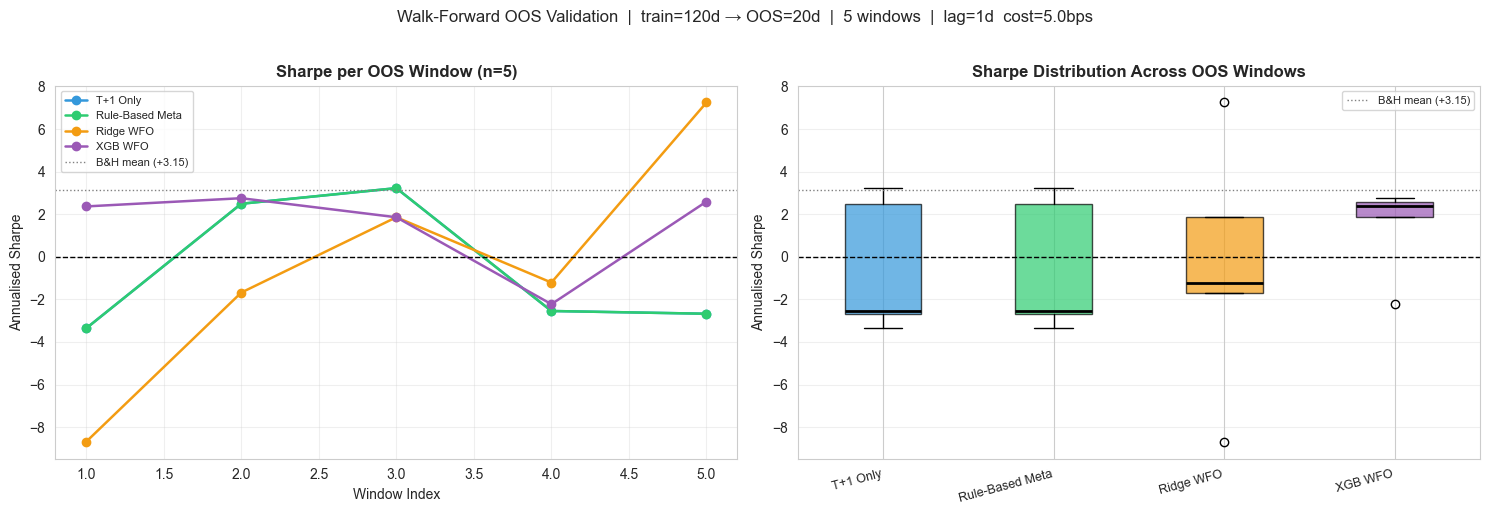

[SAVED] 02F_11_walkforward_sharpe_distribution.png


In [153]:
# ══════════════════════════════════════════════════════════════════

# Walk-Forward OOS Protocol (FIX #1)

# ══════════════════════════════════════════════════════════════════

# Replaces the unreliable single 80/20 split (47 portfolio days) with

# rolling train→test windows that re-fit Ridge + XGB in each fold.

# Reports Sharpe as a DISTRIBUTION (mean ± std) across windows,

# not a single-point estimate.

#

# Design:

#  - WF_TRAIN_DAYS : minimum trading days in each training window

#  - WF_OOS_DAYS   : OOS test window per fold (step size = same → no overlap)

#  - WF_MIN_WINDOWS: auto-scale window sizes if data is too short



WF_TRAIN_DAYS  = 120

WF_OOS_DAYS    = 20

WF_MIN_WINDOWS = 5



# ── Determine available portfolio days ──────────────────────────

all_port_dates = sig_df.groupby('date').size().index.sort_values()

n_port_days    = len(all_port_dates)



# Auto-scale when dataset is short (common in academic/demo contexts)

possible_windows = (n_port_days - WF_TRAIN_DAYS) // WF_OOS_DAYS

if possible_windows < WF_MIN_WINDOWS:

    WF_TRAIN_DAYS = max(30, int(n_port_days * 0.55))

    WF_OOS_DAYS   = max(10, (n_port_days - WF_TRAIN_DAYS) // WF_MIN_WINDOWS)



# Build rolling window index slices (non-overlapping OOS)

wf_windows = []

start_idx  = 0

while start_idx + WF_TRAIN_DAYS + WF_OOS_DAYS <= n_port_days:

    tr_dates  = all_port_dates[start_idx : start_idx + WF_TRAIN_DAYS]

    oos_dates = all_port_dates[start_idx + WF_TRAIN_DAYS :

                               start_idx + WF_TRAIN_DAYS + WF_OOS_DAYS]

    wf_windows.append((tr_dates, oos_dates))

    start_idx += WF_OOS_DAYS  # advance by OOS step → rolling origin



print(f'Portfolio days available : {n_port_days}')

print(f'Walk-forward config      : train={WF_TRAIN_DAYS}d  OOS={WF_OOS_DAYS}d  '

      f'step={WF_OOS_DAYS}d')

print(f'Windows generated        : {len(wf_windows)}')

if len(wf_windows) < WF_MIN_WINDOWS:

    print(f'[WARN] Only {len(wf_windows)} windows available — Sharpe stats have high variance.')



# ── Walk-forward loop ─────────────────────────────────────────────

wf_records = []

wf_daily_records = []



for w_idx, (tr_dates, oos_dates) in enumerate(wf_windows):



    # Per-stock slices

    wf_tr  = sig_df[sig_df['date'].isin(tr_dates)].dropna(

                subset=meta_feat_cols + ['log_ret_1d']).copy()

    wf_oos = sig_df[sig_df['date'].isin(oos_dates)].dropna(

                subset=meta_feat_cols + ['log_ret_1d']).copy()



    if len(wf_tr) < 20 or len(wf_oos) < 5:

        continue



    # Re-fit scaler and both learners independently on this fold

    X_tr  = wf_tr[meta_feat_cols].fillna(0).replace([np.inf, -np.inf], 0).values

    y_tr  = wf_tr['log_ret_1d'].values

    X_oos = wf_oos[meta_feat_cols].fillna(0).replace([np.inf, -np.inf], 0).values



    sc_wf = StandardScaler()

    X_tr_s  = sc_wf.fit_transform(X_tr)

    X_oos_s = sc_wf.transform(X_oos)



    ridge_wf = Ridge(alpha=1.0)

    ridge_wf.fit(X_tr_s, y_tr)



    xgb_wf = XGBRegressor(

        n_estimators=100, max_depth=3, learning_rate=0.05,

        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,

        random_state=42, verbosity=0)

    xgb_wf.fit(X_tr_s, y_tr)



    # Apply to OOS

    wf_oos['wf_ridge_sig'] = np.sign(ridge_wf.predict(X_oos_s))

    wf_oos['wf_xgb_sig']   = np.sign(xgb_wf.predict(X_oos_s))



    # Portfolio aggregation (equal-weight)

    oos_port = wf_oos.groupby('date').agg(

        t1_bin   =('signal_t1',    lambda x: np.sign(x.mean())),

        meta_bin =('meta_signal',  lambda x: np.sign(x.mean())),

        ridge_bin=('wf_ridge_sig', lambda x: np.sign(x.mean())),

        xgb_bin  =('wf_xgb_sig',   lambda x: np.sign(x.mean())),

        actual_ret=('log_ret_1d',  'mean'),

    ).sort_values('date').reset_index()



    daily_signal_map = {

        'T+1 Only': oos_port['t1_bin'],

        'Rule-Based Meta': oos_port['meta_bin'],

        'Ridge WFO': oos_port['ridge_bin'],

        'XGB WFO': oos_port['xgb_bin'],

    }

    for sig_label, series in daily_signal_map.items():

        wf_daily_records.append(pd.DataFrame({

            'Window': w_idx + 1,

            'date': oos_port['date'].values,

            'Strategy': sig_label,

            'signal': np.asarray(series.values, dtype=float),

            'actual_ret': oos_port['actual_ret'].values,

        }))



    for sig_col_wf, sig_label in [

        ('t1_bin',    'T+1 Only'),

        ('meta_bin',  'Rule-Based Meta'),

        ('ridge_bin', 'Ridge WFO'),

        ('xgb_bin',   'XGB WFO'),

    ]:

        sbt = run_backtest(

            oos_port[sig_col_wf].values,

            oos_port['actual_ret'].values,

            oos_port['date'].values,

            name=sig_label,

            execution_lag_days=EXECUTION_LAG_DAYS,

            tcost_bps_one_way=TCOST_BPS_ONE_WAY,

            min_signal_abs=MIN_SIGNAL_ABS,

        )

        wf_records.append({

            'Window'     : w_idx + 1,

            'Train_Start': str(tr_dates[0].date()),

            'Train_End'  : str(tr_dates[-1].date()),

            'OOS_Start'  : str(oos_dates[0].date()),

            'OOS_End'    : str(oos_dates[-1].date()),

            'Strategy'   : sig_label,

            'Sharpe'     : sbt['sharpe'],

            'DHR'        : sbt['dhr'],

            'Max_DD'     : sbt['max_drawdown'],

            'Total_Ret'  : sbt['total_return'],

            'BH_Sharpe'  : sbt['bh_sharpe'],

            'N_OOS_Days' : len(oos_port),

        })



wf_df = pd.DataFrame(wf_records)

wf_daily_df = pd.concat(wf_daily_records, ignore_index=True) if wf_daily_records else pd.DataFrame()

n_complete = wf_df['Window'].nunique()

print(f'\nWalk-forward complete: {n_complete} windows × 4 strategies')

print()



# Build stitched daily WFO XGB series for downstream reporting.

wfo_xgb_daily = wf_daily_df[wf_daily_df['Strategy'] == 'XGB WFO'].copy()

if len(wfo_xgb_daily) > 0:

    wfo_xgb_daily = wfo_xgb_daily.sort_values('date').drop_duplicates(subset=['date'], keep='last')

    wfo_xgb_bt = run_backtest(

        wfo_xgb_daily['signal'].values,

        wfo_xgb_daily['actual_ret'].values,

        wfo_xgb_daily['date'].values,

        name='Learned Meta XGB (02F) [WFO Stitched]',

        execution_lag_days=EXECUTION_LAG_DAYS,

        tcost_bps_one_way=TCOST_BPS_ONE_WAY,

        min_signal_abs=MIN_SIGNAL_ABS,

    )

    wfo_xgb_bt['name'] = 'Learned Meta XGB (02F) [WFO Stitched]'

    print('Stitched WFO XGB backtest ready for downstream reporting.')

    print(

        f"Sharpe={wfo_xgb_bt['sharpe']:+.3f}  MaxDD={wfo_xgb_bt['max_drawdown']:+.2%}  "

        f"Return={wfo_xgb_bt['total_return']:+.2%}  DHR={wfo_xgb_bt['dhr']:.1%}"

    )

else:

    wfo_xgb_bt = None

    print('[WARN] No stitched WFO XGB daily series was created.')



# ── Sharpe distribution table ─────────────────────────────────────

wf_summary = (

    wf_df.groupby('Strategy')['Sharpe']

    .agg(Mean='mean', Std='std', Min='min', Max='max',

         Win_Rate=lambda x: (x > 0).mean())

    .round(3)

)

wf_summary['Mean±Std'] = (

    wf_summary['Mean'].map('{:+.3f}'.format) + ' ± ' +

    wf_summary['Std'].map('{:.3f}'.format)

)

wf_summary['95%CI'] = (

    '[' + (wf_summary['Mean'] - 1.96*wf_summary['Std']).map('{:+.2f}'.format) +

    ', ' + (wf_summary['Mean'] + 1.96*wf_summary['Std']).map('{:+.2f}'.format) + ']'

)

print('── Walk-Forward Sharpe Distribution ─────────────────────────────')

print(wf_summary[['Mean±Std', 'Min', 'Max', 'Win_Rate', '95%CI']].to_string())



bh_mean = wf_df.groupby('Window')['BH_Sharpe'].first().mean()

print(f'\nBuy & Hold Sharpe (mean across windows): {bh_mean:+.3f}')



# Save

wf_path = data_dir / '02F_walkforward_oos.csv'

wf_df.to_csv(wf_path, index=False)

print(f'\n[SAVED] {wf_path.name}')



# ── Visualisation ─────────────────────────────────────────────────

strategies_wf = wf_df['Strategy'].unique().tolist()

colors_wf     = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']



fig, axes = plt.subplots(1, 2, figsize=(15, 5))



# Panel 1: per-window Sharpe line chart

for strat, color in zip(strategies_wf, colors_wf):

    sub = wf_df[wf_df['Strategy'] == strat].sort_values('Window')

    axes[0].plot(sub['Window'], sub['Sharpe'], marker='o', linewidth=1.8,

                 label=strat, color=color)

axes[0].axhline(0, color='black', linewidth=1, linestyle='--')

axes[0].axhline(bh_mean, color='grey', linewidth=1, linestyle=':', label=f'B&H mean ({bh_mean:+.2f})')

axes[0].set_xlabel('Window Index')

axes[0].set_ylabel('Annualised Sharpe')

axes[0].set_title(f'Sharpe per OOS Window (n={n_complete})')

axes[0].legend(fontsize=8)

axes[0].grid(True, alpha=0.3)



# Panel 2: box plot distribution

box_data   = [wf_df[wf_df['Strategy'] == s]['Sharpe'].values for s in strategies_wf]

bp = axes[1].boxplot(box_data, patch_artist=True, notch=False,

                     medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colors_wf):

    patch.set_facecolor(color)

    patch.set_alpha(0.7)

axes[1].axhline(0, color='black', linewidth=1, linestyle='--')

axes[1].axhline(bh_mean, color='grey', linewidth=1, linestyle=':', label=f'B&H mean ({bh_mean:+.2f})')

axes[1].set_xticks(range(1, len(strategies_wf)+1))

axes[1].set_xticklabels(strategies_wf, rotation=15, ha='right', fontsize=9)

axes[1].set_ylabel('Annualised Sharpe')

axes[1].set_title('Sharpe Distribution Across OOS Windows')

axes[1].legend(fontsize=8)

axes[1].grid(True, axis='y', alpha=0.3)



plt.suptitle(

    f'Walk-Forward OOS Validation  |  train={WF_TRAIN_DAYS}d → OOS={WF_OOS_DAYS}d  '

    f'|  {n_complete} windows  |  lag={EXECUTION_LAG_DAYS}d  cost={TCOST_BPS_ONE_WAY}bps',

    fontsize=12, y=1.02

)

plt.tight_layout()

plt.savefig(graph_dir / '02F_11_walkforward_sharpe_distribution.png', dpi=120, bbox_inches='tight')

plt.show()

print('[SAVED] 02F_11_walkforward_sharpe_distribution.png')


Transaction Cost Sensitivity — Learned Meta XGB (02F) [WFO Stitched]
(Buy & Hold Sharpe reference: +2.6058)

 TCost_bps    Sharpe  Max_Drawdown  Total_Return  Annual_Vol      DHR  Beats_BH
         0  2.651400     -0.022500      0.072200    0.067100 0.596000      True
         5  2.186700     -0.023500      0.058900    0.067000 0.596000     False
        10  1.709800     -0.024600      0.045800    0.067300 0.596000     False
        20  0.754200     -0.028600      0.019900    0.069000 0.596000     False
        30 -0.152000     -0.035700     -0.005400    0.072200 0.596000     False

Alpha survives (Sharpe >= B&H) up to 0 bps one-way


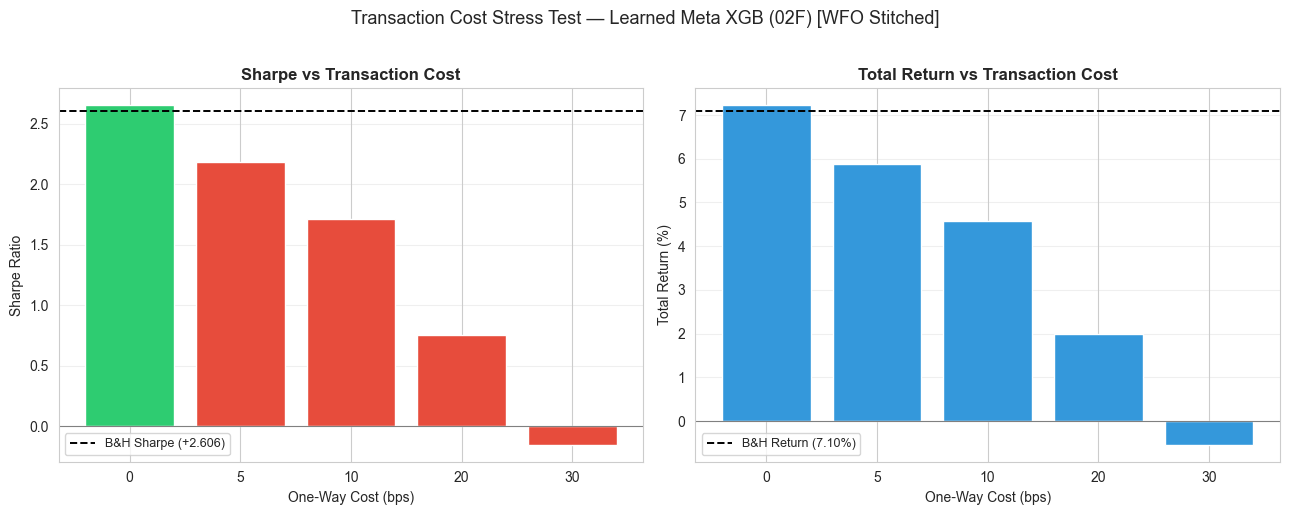

[SAVED] 02F_09_cost_stress_test.png


In [148]:
# ══════════════════════════════════════════════════════════════════

# Transaction Cost Sensitivity — Stress Test (FIX #4)

# ══════════════════════════════════════════════════════════════════

# Runs the stitched WFO XGB strategy at 0 / 5 / 10 / 20 / 30 bps one-way

# to assess how fragile the alpha is to execution friction assumptions.



stress_scenarios = [0, 5, 10, 20, 30]



if 'wfo_xgb_daily' not in globals() or len(wfo_xgb_daily) == 0:

    raise RuntimeError('Stitched WFO XGB daily series not found. Run Cell 12 first.')



primary_signal   = wfo_xgb_daily['signal'].values

primary_returns  = wfo_xgb_daily['actual_ret'].values

primary_dates    = wfo_xgb_daily['date'].values

primary_name     = 'Learned Meta XGB (02F) [WFO Stitched]'

bh_ref_bt        = run_backtest(

    np.zeros(len(primary_signal)),

    primary_returns,

    primary_dates,

    name='Buy & Hold Reference',

    execution_lag_days=0,

    tcost_bps_one_way=0.0,

    min_signal_abs=0.0,

)

bh_sharpe_ref    = bh_ref_bt['bh_sharpe']



stress_rows = []

for tcost in stress_scenarios:

    sb = run_backtest(

        primary_signal,

        primary_returns,

        primary_dates,

        name=f'{primary_name} @ {tcost}bps',

        execution_lag_days=EXECUTION_LAG_DAYS,

        tcost_bps_one_way=tcost,

        min_signal_abs=MIN_SIGNAL_ABS,

    )

    stress_rows.append({

        'TCost_bps':    tcost,

        'Sharpe':       sb['sharpe'],

        'Max_Drawdown': sb['max_drawdown'],

        'Total_Return': sb['total_return'],

        'Annual_Vol':   sb['annual_vol'],

        'DHR':          sb['dhr'],

        'Beats_BH':     sb['sharpe'] >= bh_sharpe_ref,

    })



stress_df = pd.DataFrame(stress_rows)

print(f'Transaction Cost Sensitivity — {primary_name}')

print(f'(Buy & Hold Sharpe reference: {bh_sharpe_ref:+.4f})')

print()

print(stress_df.to_string(index=False))



above_bh = stress_df[stress_df['Beats_BH']]

breakeven = above_bh['TCost_bps'].max() if len(above_bh) else 'Never'

print(f'\nAlpha survives (Sharpe >= B&H) up to {breakeven} bps one-way')



# ── Visualisation ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_labels  = [str(t) for t in stress_df['TCost_bps']]



bar_colors = ['#2ecc71' if b else '#e74c3c' for b in stress_df['Beats_BH']]

axes[0].bar(x_labels, stress_df['Sharpe'], color=bar_colors, edgecolor='white')

axes[0].axhline(bh_sharpe_ref, color='black', linestyle='--', linewidth=1.4,

                label=f'B&H Sharpe ({bh_sharpe_ref:+.3f})')

axes[0].axhline(0, color='grey', linewidth=0.8)

axes[0].set_xlabel('One-Way Cost (bps)')

axes[0].set_ylabel('Sharpe Ratio')

axes[0].set_title('Sharpe vs Transaction Cost')

axes[0].legend(fontsize=9)

axes[0].grid(True, axis='y', alpha=0.3)



axes[1].bar(x_labels, stress_df['Total_Return'] * 100, color='#3498db', edgecolor='white')

bh_ret_pct = bh_ref_bt['bh_return'] * 100

axes[1].axhline(bh_ret_pct, color='black', linestyle='--', linewidth=1.4,

                label=f'B&H Return ({bh_ret_pct:.2f}%)')

axes[1].axhline(0, color='grey', linewidth=0.8)

axes[1].set_xlabel('One-Way Cost (bps)')

axes[1].set_ylabel('Total Return (%)')

axes[1].set_title('Total Return vs Transaction Cost')

axes[1].legend(fontsize=9)

axes[1].grid(True, axis='y', alpha=0.3)



plt.suptitle(f'Transaction Cost Stress Test — {primary_name}', fontsize=13, y=1.02)

plt.tight_layout()

plt.savefig(graph_dir / '02F_09_cost_stress_test.png', dpi=120, bbox_inches='tight')

plt.show()

print('[SAVED] 02F_09_cost_stress_test.png')


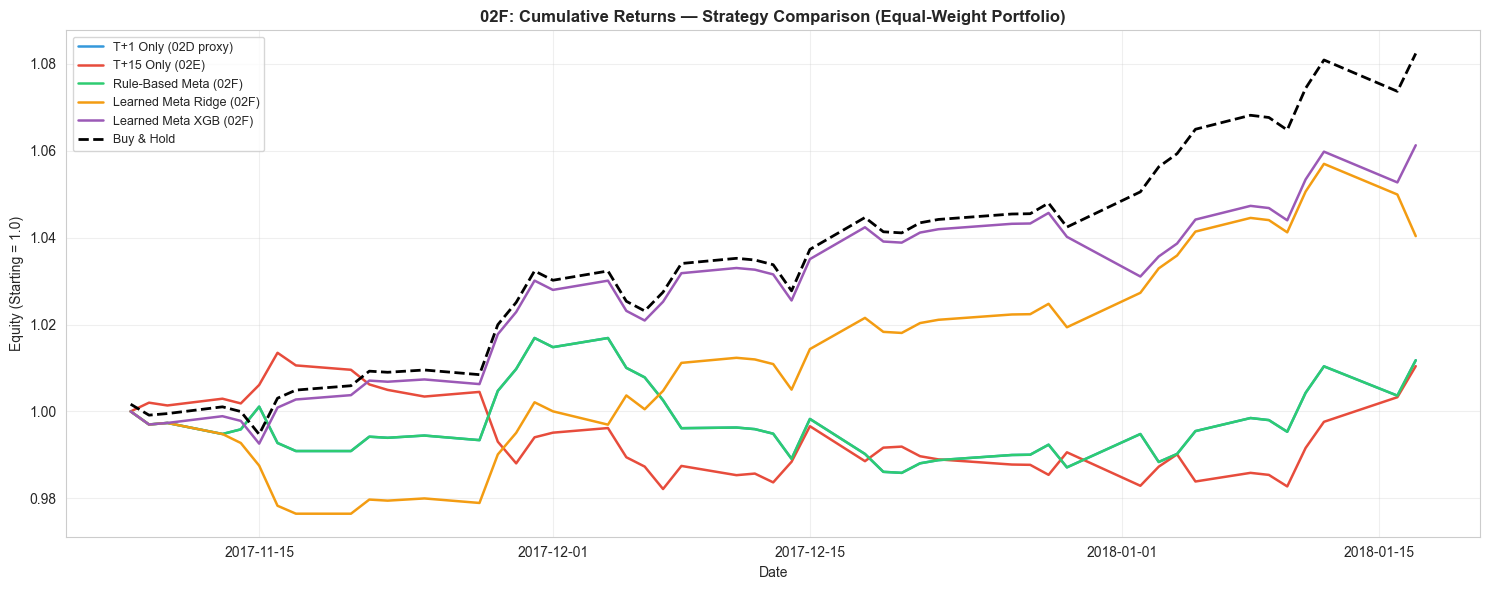

In [133]:
# ── Cumulative Return Chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
for (name, bt), color in zip(bt_results.items(), colors):
    ax.plot(bt['dates'], bt['equity'], label=name, linewidth=1.8, color=color)

# Buy & hold
first_bt = list(bt_results.values())[0]
ax.plot(first_bt['dates'], first_bt['bh_equity'],
        label='Buy & Hold', linewidth=2.0, color='black', linestyle='--')

ax.set_title('02F: Cumulative Returns — Strategy Comparison (Equal-Weight Portfolio)')
ax.set_xlabel('Date')
ax.set_ylabel('Equity (Starting = 1.0)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(graph_dir / '02F_01_cumulative_returns.png', dpi=120, bbox_inches='tight')
plt.show()


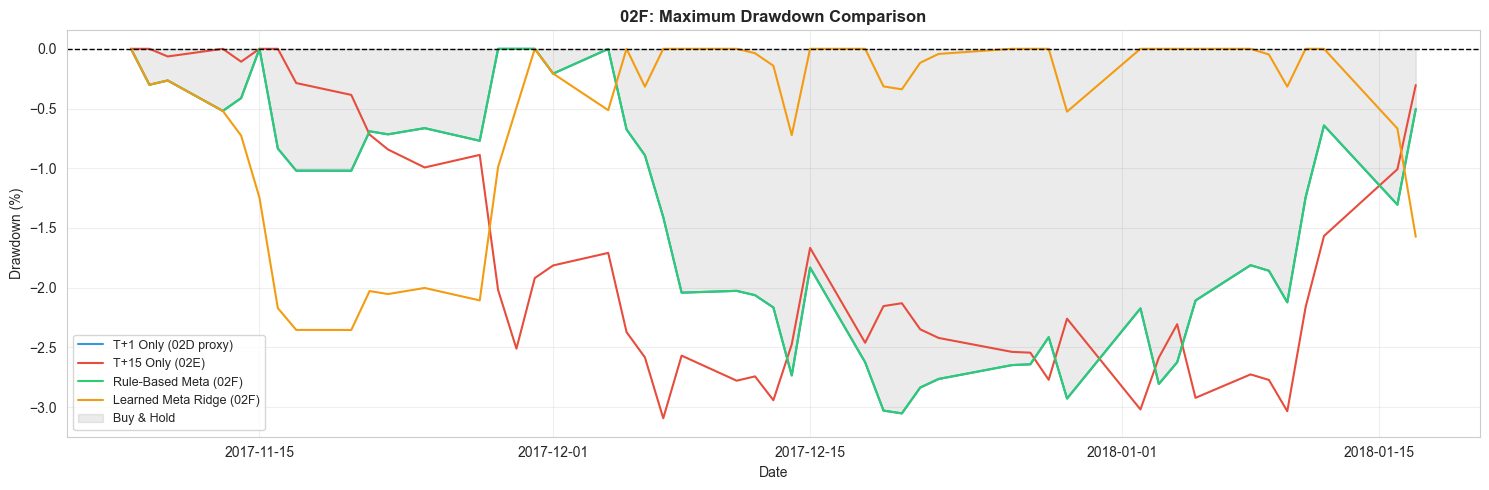

In [134]:
# ── Drawdown Chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))
for (name, bt), color in zip(list(bt_results.items())[:4], colors[:4]):
    ax.plot(bt['dates'], bt['drawdown'] * 100,
            label=name, linewidth=1.5, color=color)
ax.fill_between(first_bt['dates'], first_bt['drawdown'] * 100, 0,
                color='black', alpha=0.08, label='Buy & Hold')
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('02F: Maximum Drawdown Comparison')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(graph_dir / '02F_02_drawdown.png', dpi=120, bbox_inches='tight')
plt.show()


Performance by VIX Regime:
Regime Strategy   Sharpe      DHR  N_Days
   Low 02F Meta 2.394000 0.574000      47
   Low T+1 Only 2.394000 0.574000      47


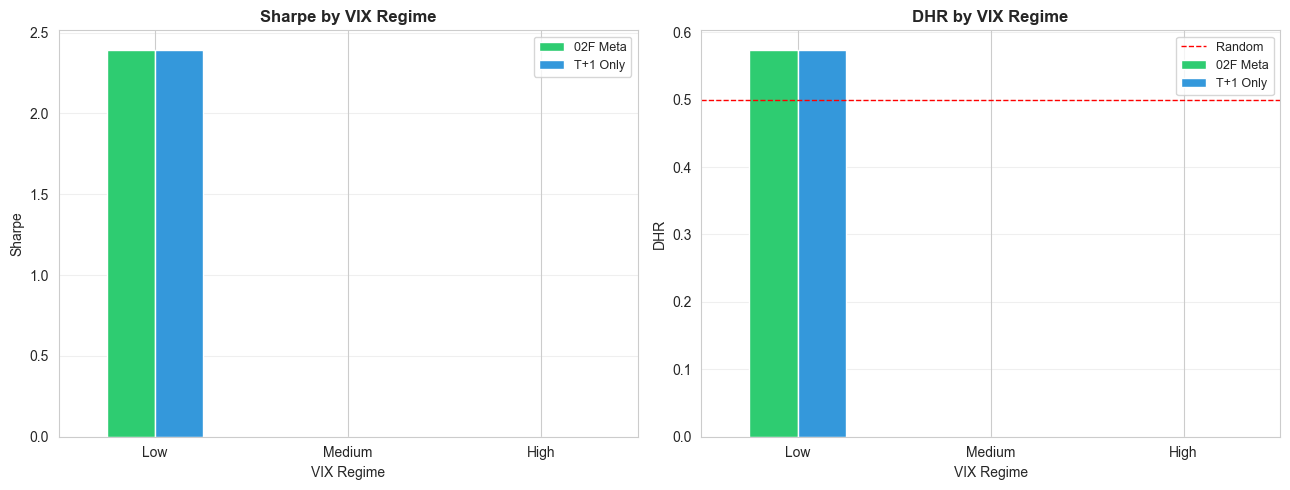

In [135]:
# ── Performance by VIX Regime ────────────────────────────────────
# Does the meta-signal improve most in high-VIX periods?
regime_records = []
for regime_label in ['Low', 'Medium', 'High']:
    mask = test_sig['vix_regime'] == regime_label
    if mask.sum() < 10:
        continue
    sub = test_sig[mask]
    sub_port = sub.groupby('date').agg(
        meta_signal=('meta_signal', lambda x: np.sign(x.mean())),
        signal_t1=('signal_t1', lambda x: np.sign(x.mean())),
        actual_ret=('log_ret_1d', 'mean'),
    ).reset_index()

    for sig_col, sig_name in [('meta_signal', '02F Meta'), ('signal_t1', 'T+1 Only')]:
        pnl = sub_port[sig_col] * sub_port['actual_ret']
        sharpe = (pnl.mean() / (pnl.std() + 1e-8)) * np.sqrt(252)
        dhr = (np.sign(sub_port['actual_ret']) == sub_port[sig_col]).mean()
        regime_records.append(dict(
            Regime=regime_label, Strategy=sig_name,
            Sharpe=round(float(sharpe), 3), DHR=round(float(dhr), 3),
            N_Days=len(sub_port)
        ))

regime_df = pd.DataFrame(regime_records)
print('Performance by VIX Regime:')
print(regime_df.to_string(index=False))

# Bar chart
if len(regime_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, metric in zip(axes, ['Sharpe', 'DHR']):
        pivot = regime_df.pivot(index='Regime', columns='Strategy', values=metric)
        pivot = pivot.reindex(['Low', 'Medium', 'High'])
        pivot.plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db'])
        ax.set_title(f'{metric} by VIX Regime')
        ax.set_ylabel(metric)
        ax.set_xlabel('VIX Regime')
        ax.tick_params(axis='x', rotation=0)
        if metric == 'DHR':
            ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random')
        ax.legend(fontsize=9)
        ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(graph_dir / '02F_03_vix_regime_performance.png', dpi=120, bbox_inches='tight')
    plt.show()


False breakout rate in test set: 32.9%
Meta-signal suppression rate on false breakouts: 0.0%
Avg daily PnL on false-breakout days:
  T+1 signal:  +0.00299
  Meta signal: +0.00299
  Improvement: +0.00000


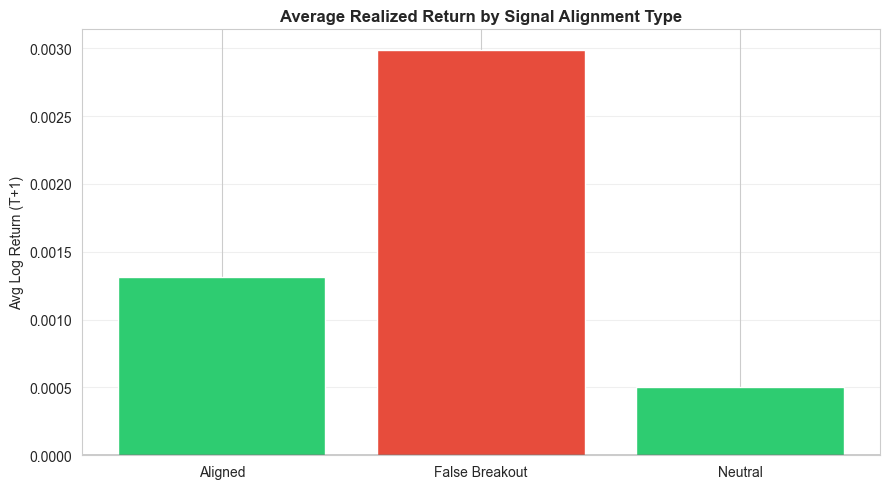

In [136]:
# ══════════════════════════════════════════════════════════════════
# False Breakout Suppression Analysis
# ══════════════════════════════════════════════════════════════════
# A false breakout: T+1 predicts UP (+1) but T+15 is negative (down move)

fb_test = test_sig.copy()
fb_test['is_false_breakout'] = (
    (fb_test['signal_t1'] > 0) & (fb_test['pred_T15'] < 0)
).astype(int)

fb_rate = fb_test['is_false_breakout'].mean()
print(f'False breakout rate in test set: {fb_rate:.1%}')

# Did the meta-signal correctly suppress these?
fb_days = fb_test[fb_test['is_false_breakout'] == 1]
meta_suppressed = (fb_days['meta_signal'] != fb_days['signal_t1']).mean()
print(f'Meta-signal suppression rate on false breakouts: {meta_suppressed:.1%}')

# P&L comparison: T+1 vs Meta on false-breakout days
if len(fb_days) > 0:
    pnl_t1_fb   = (fb_days['signal_t1']   * fb_days['log_ret_1d']).mean()
    pnl_meta_fb = (fb_days['meta_signal']  * fb_days['log_ret_1d']).mean()
    print(f'Avg daily PnL on false-breakout days:')
    print(f'  T+1 signal:  {pnl_t1_fb:+.5f}')
    print(f'  Meta signal: {pnl_meta_fb:+.5f}')
    print(f'  Improvement: {pnl_meta_fb - pnl_t1_fb:+.5f}')

# Bar chart: realized returns on false-breakout vs aligned days
fb_test['signal_type'] = np.where(
    fb_test['is_false_breakout'] == 1, 'False Breakout',
    np.where(fb_test['signal_t1'] == np.sign(fb_test['pred_T15']), 'Aligned', 'Neutral')
)
grouped = fb_test.groupby('signal_type')['log_ret_1d'].mean()
fig, ax = plt.subplots(figsize=(9, 5))
colors_fb = ['#e74c3c' if t == 'False Breakout' else '#2ecc71' for t in grouped.index]
ax.bar(grouped.index, grouped.values, color=colors_fb)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Average Realized Return by Signal Alignment Type')
ax.set_ylabel('Avg Log Return (T+1)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(graph_dir / '02F_04_false_breakout.png', dpi=120, bbox_inches='tight')
plt.show()


Per-Stock Sharpe (lag=1d, cost=5.0bps):
Strategy  02F Meta       T+1       T+15
Stock                                  
A         1.448200  1.448200   1.431800
AAL      -0.250300 -0.250300   3.392700
AAP      -2.468900 -2.468900   1.428300
AAPL     -3.208400 -3.208400   1.439100
ABBV     -3.695200 -3.695200  -3.416100
ABC       5.342300  5.342300  -3.689900
ABT      -1.474500 -1.474500  -3.812200
ACN       1.267900  1.267900  -3.687000
ADBE      2.663400  2.663400   6.346100
ADI       0.252500  0.252500   1.845500
ADM       1.758600  1.758600   3.035400
ADP      -0.944500 -0.944500   2.481100
ADS      -0.199500 -0.199500  -1.814300
ADSK     -0.478600 -0.478600   1.237100
AEE      -3.438700 -3.438700  -1.855200
AEP       1.187700  1.187700  -0.780800
AES      -7.039900 -7.039900   1.854400
AET      -1.273700 -1.273700  -1.742600
AFL       0.314800  0.314800   2.133600
AGN      -4.878000 -4.878000  -6.087700
AIG      -1.449000 -1.449000  -0.727600
AIV       0.095100  0.095100  -4.450600


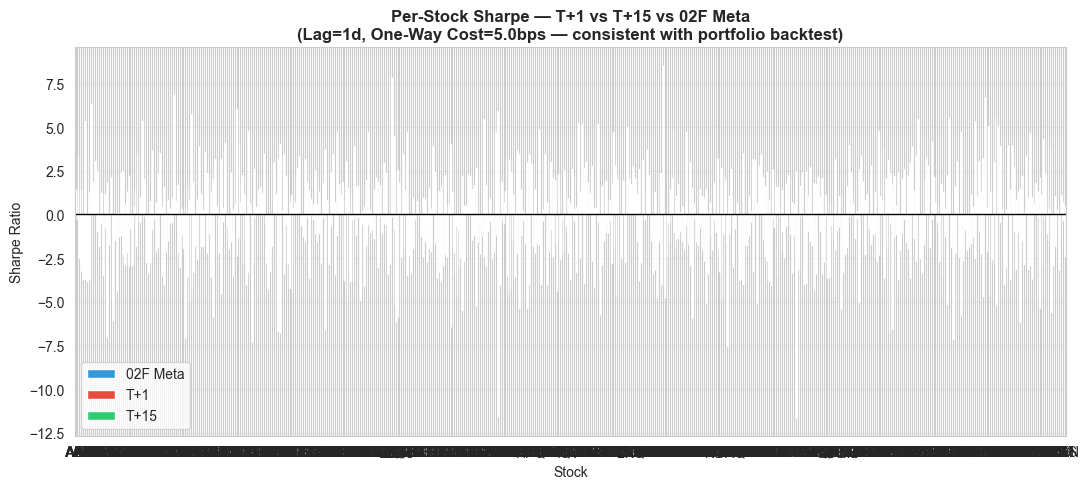

In [137]:
# ── Per-Stock Backtest Results (FIX #5: consistent lag + cost) ───
# Previously used raw signal × return without execution lag or costs,
# inflating per-stock Sharpe vs the realistic portfolio-level results.
# Now uses run_backtest() with the same EXECUTION_LAG_DAYS / TCOST_BPS_ONE_WAY
# so all reported numbers are on a consistent footing.

stock_bt_records = []
for stock in sorted(test_sig['Name'].unique()):
    sub = test_sig[test_sig['Name'] == stock].sort_values('date')
    if len(sub) < 3:
        continue
    for sig_col, sig_name in [
        ('signal_t1',   'T+1'),
        ('signal_t15',  'T+15'),
        ('meta_signal', '02F Meta'),
    ]:
        sbt = run_backtest(
            sub[sig_col].values,
            sub['log_ret_1d'].values,
            sub['date'].values,
            name=f'{stock} {sig_name}',
            execution_lag_days=EXECUTION_LAG_DAYS,
            tcost_bps_one_way=TCOST_BPS_ONE_WAY,
            min_signal_abs=MIN_SIGNAL_ABS,
        )
        stock_bt_records.append(dict(
            Stock=stock, Strategy=sig_name,
            Sharpe=sbt['sharpe'],
            DHR=sbt['dhr'],
            Total_Return=sbt['total_return'],
            N=len(sub),
        ))

stock_bt_df = pd.DataFrame(stock_bt_records)
pivot_sharpe = stock_bt_df.pivot(index='Stock', columns='Strategy', values='Sharpe')
print(f'Per-Stock Sharpe (lag={EXECUTION_LAG_DAYS}d, cost={TCOST_BPS_ONE_WAY}bps):')
print(pivot_sharpe.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
pivot_sharpe.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'])
ax.axhline(0, color='black', linewidth=1)
ax.set_title(
    f'Per-Stock Sharpe — T+1 vs T+15 vs 02F Meta\n'
    f'(Lag={EXECUTION_LAG_DAYS}d, One-Way Cost={TCOST_BPS_ONE_WAY}bps — consistent with portfolio backtest)'
)
ax.set_ylabel('Sharpe Ratio')
ax.tick_params(axis='x', rotation=0)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(graph_dir / '02F_05_per_stock_sharpe.png', dpi=120, bbox_inches='tight')
plt.show()


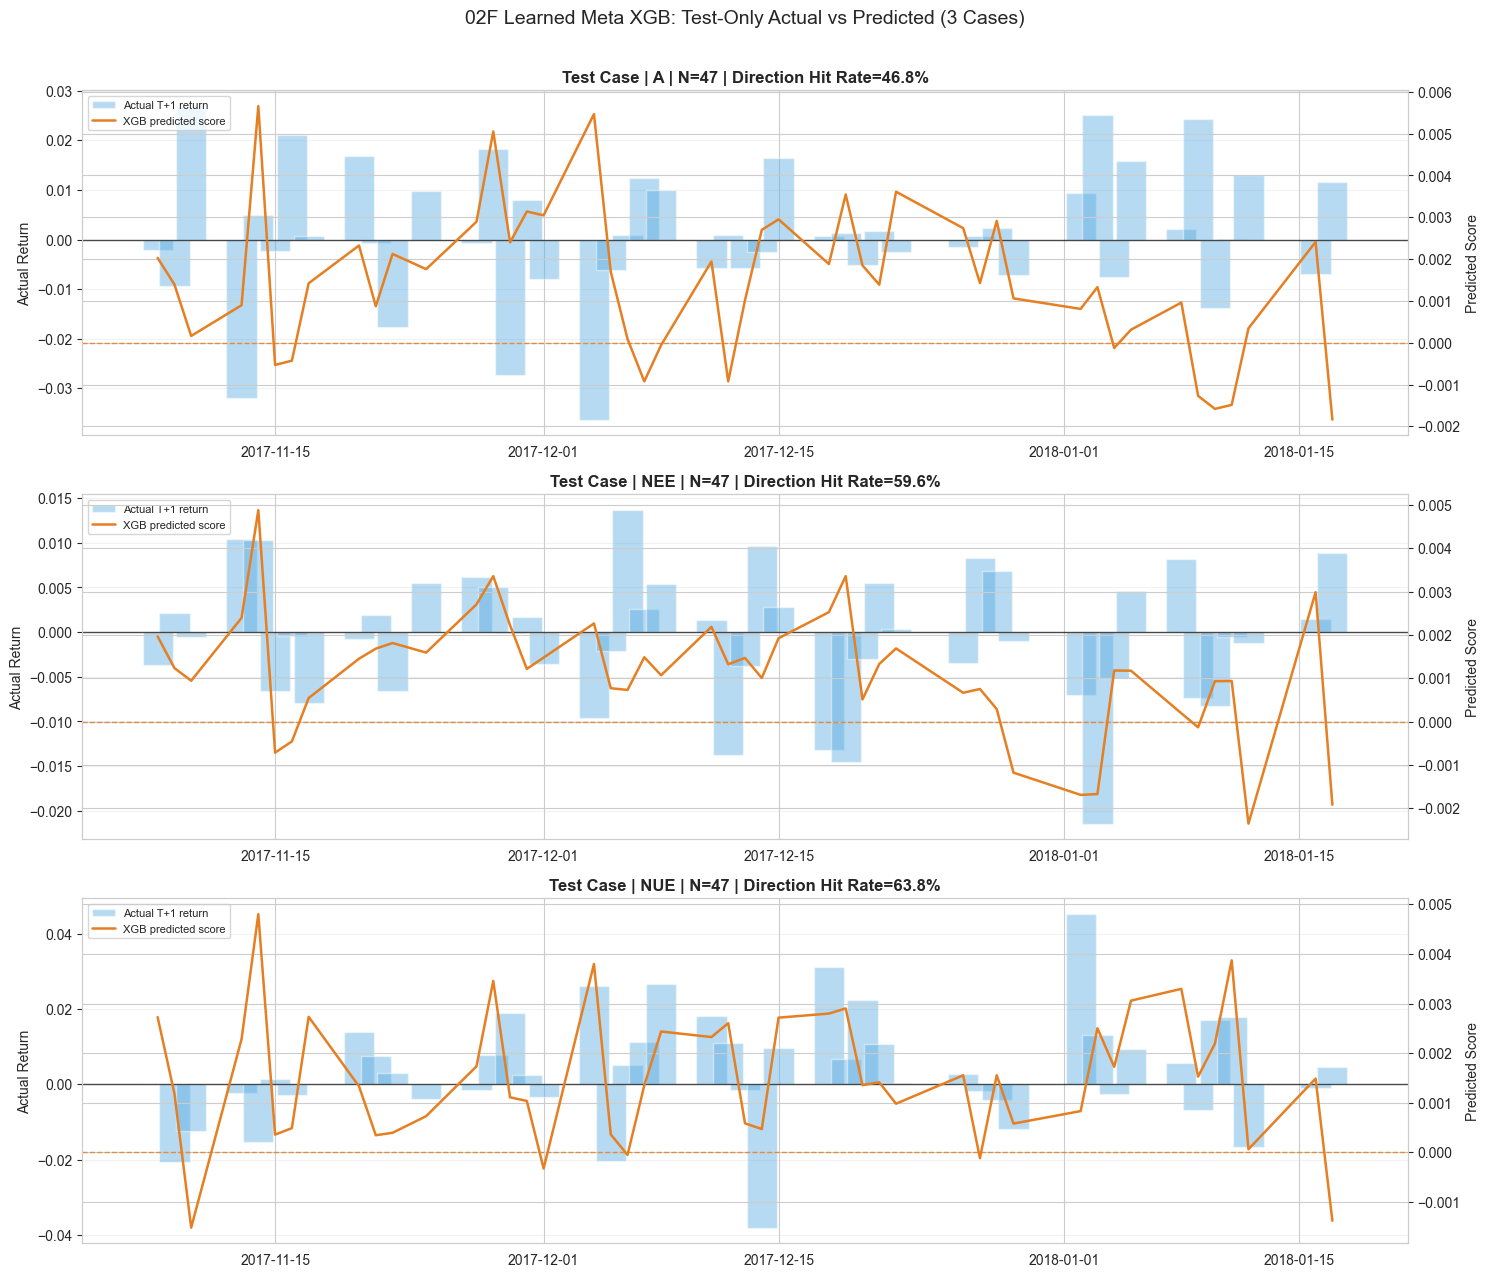

Selected test-case stocks: A, NEE, NUE
[SAVED] 02F_06_test_cases_actual_vs_xgb_prediction.png


In [138]:
# ── Test-Only Case Plots: Actual vs XGB Prediction (2-3 stocks) ───
# This section uses ONLY the meta_test split (post split_date).

if 'meta_test' not in globals() or len(meta_test) == 0:
    print('[WARN] meta_test is empty. Run the meta-learner cell first.')
else:
    case_df = meta_test.copy().sort_values(['Name', 'date'])

    # Attach raw XGB prediction score if available in memory.
    if 'xgb_pred_score' not in case_df.columns:
        if 'xgb_meta_preds' in globals() and len(xgb_meta_preds) == len(case_df):
            case_df['xgb_pred_score'] = xgb_meta_preds
        elif 'xgb_meta' in globals() and 'scaler_m' in globals() and 'meta_feat_cols' in globals():
            X_case = case_df[meta_feat_cols].fillna(0).replace([np.inf, -np.inf], 0)
            X_case_scaled = scaler_m.transform(X_case)
            case_df['xgb_pred_score'] = xgb_meta.predict(X_case_scaled)
        else:
            case_df['xgb_pred_score'] = np.nan

    case_df['actual_dir'] = np.sign(case_df['log_ret_1d'])
    if 'xgb_learned_signal' in case_df.columns:
        case_df['pred_dir'] = case_df['xgb_learned_signal']
    else:
        case_df['pred_dir'] = np.sign(case_df['xgb_pred_score'])

    case_df['is_hit'] = (case_df['actual_dir'] == case_df['pred_dir']).astype(int)

    # Pick 3 representative test cases: stocks with most test observations.
    case_stocks = case_df['Name'].value_counts().head(3).index.tolist()
    if len(case_stocks) == 0:
        print('[WARN] No test-stock rows available for plotting.')
    else:
        fig, axes = plt.subplots(len(case_stocks), 1, figsize=(15, 4.2 * len(case_stocks)), sharex=False)
        if len(case_stocks) == 1:
            axes = [axes]

        for ax, stock in zip(axes, case_stocks):
            sub = case_df[case_df['Name'] == stock].sort_values('date').copy()

            # Left axis: realized next-day return
            ax.bar(sub['date'], sub['log_ret_1d'], width=1.8, color='#5dade2', alpha=0.45, label='Actual T+1 return')
            ax.axhline(0, color='black', linewidth=1, alpha=0.7)
            ax.set_ylabel('Actual Return')

            # Right axis: XGB prediction score
            ax2 = ax.twinx()
            ax2.plot(sub['date'], sub['xgb_pred_score'], color='#e67e22', linewidth=1.8, label='XGB predicted score')
            ax2.axhline(0, color='#e67e22', linestyle='--', linewidth=1, alpha=0.8)
            ax2.set_ylabel('Predicted Score')

            hit_rate = sub['is_hit'].mean() if len(sub) > 0 else np.nan
            ax.set_title(f'Test Case | {stock} | N={len(sub)} | Direction Hit Rate={hit_rate:.1%}')
            ax.grid(True, axis='y', alpha=0.25)

            # Combined legend (left + right axes)
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()
            ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)

        plt.suptitle('02F Learned Meta XGB: Test-Only Actual vs Predicted (3 Cases)', y=1.01, fontsize=14)
        plt.tight_layout()
        plt.savefig(graph_dir / '02F_06_test_cases_actual_vs_xgb_prediction.png', dpi=120, bbox_inches='tight')
        plt.show()

        print('Selected test-case stocks:', ', '.join(case_stocks))
        print('[SAVED] 02F_06_test_cases_actual_vs_xgb_prediction.png')

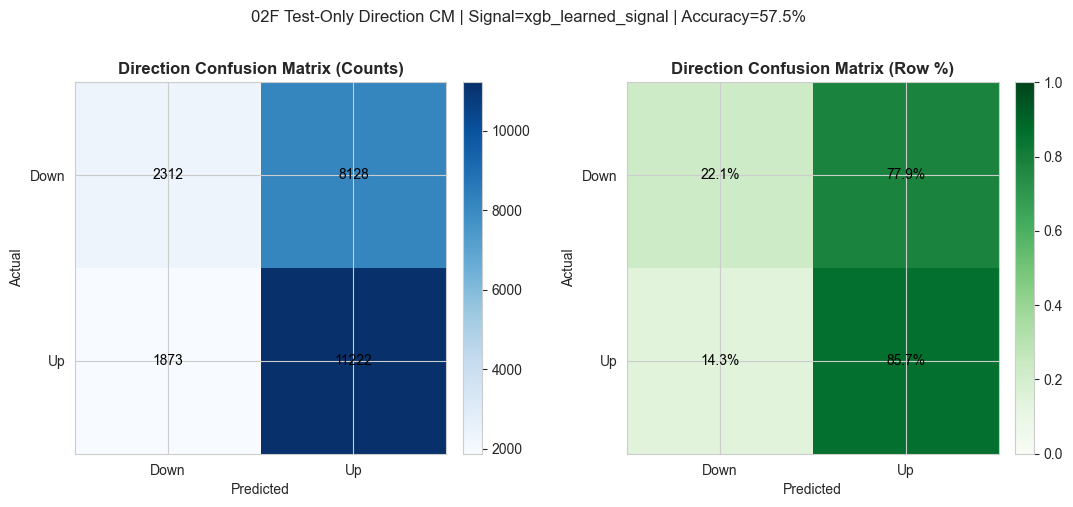

Test rows used: 23535
Direction accuracy: 57.5%
[SAVED] 02F_07_test_direction_confusion_matrix.png


In [139]:
# ── Confusion-Matrix Style Direction Chart (Test Set Only) ─────────
# Rows = Actual direction, Columns = Predicted direction

cm_source = test_sig.copy() if 'test_sig' in globals() else pd.DataFrame()

if len(cm_source) == 0:
    print('[WARN] test_sig is empty. Run backtest-prep cells first.')
else:
    target_col = 'xgb_learned_signal' if 'xgb_learned_signal' in cm_source.columns else 'meta_signal'

    cm_df = cm_source[['log_ret_1d', target_col]].dropna().copy()
    cm_df = cm_df[(cm_df['log_ret_1d'] != 0) & (cm_df[target_col] != 0)]

    if len(cm_df) == 0:
        print('[WARN] No non-zero direction rows available for confusion matrix.')
    else:
        cm_df['actual'] = np.where(cm_df['log_ret_1d'] > 0, 'Up', 'Down')
        cm_df['pred'] = np.where(cm_df[target_col] > 0, 'Up', 'Down')

        labels = ['Down', 'Up']
        counts = pd.crosstab(
            pd.Categorical(cm_df['actual'], categories=labels, ordered=True),
            pd.Categorical(cm_df['pred'], categories=labels, ordered=True),
            dropna=False
        ).reindex(index=labels, columns=labels, fill_value=0)

        rates = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
        acc = float((cm_df['actual'] == cm_df['pred']).mean())

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

        # Panel 1: counts
        im0 = axes[0].imshow(counts.values, cmap='Blues')
        axes[0].set_title('Direction Confusion Matrix (Counts)')
        axes[0].set_xticks(range(2))
        axes[0].set_yticks(range(2))
        axes[0].set_xticklabels(labels)
        axes[0].set_yticklabels(labels)
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        for i in range(2):
            for j in range(2):
                axes[0].text(j, i, f"{int(counts.iloc[i, j])}", ha='center', va='center', color='black')
        fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

        # Panel 2: row-normalized rates
        im1 = axes[1].imshow(rates.values, cmap='Greens', vmin=0, vmax=1)
        axes[1].set_title('Direction Confusion Matrix (Row %)')
        axes[1].set_xticks(range(2))
        axes[1].set_yticks(range(2))
        axes[1].set_xticklabels(labels)
        axes[1].set_yticklabels(labels)
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Actual')
        for i in range(2):
            for j in range(2):
                axes[1].text(j, i, f"{rates.iloc[i, j] * 100:.1f}%", ha='center', va='center', color='black')
        fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

        fig.suptitle(f'02F Test-Only Direction CM | Signal={target_col} | Accuracy={acc:.1%}', y=1.03)
        plt.tight_layout()
        plt.savefig(graph_dir / '02F_07_test_direction_confusion_matrix.png', dpi=120, bbox_inches='tight')
        plt.show()

        print(f'Test rows used: {len(cm_df)}')
        print(f'Direction accuracy: {acc:.1%}')
        print('[SAVED] 02F_07_test_direction_confusion_matrix.png')

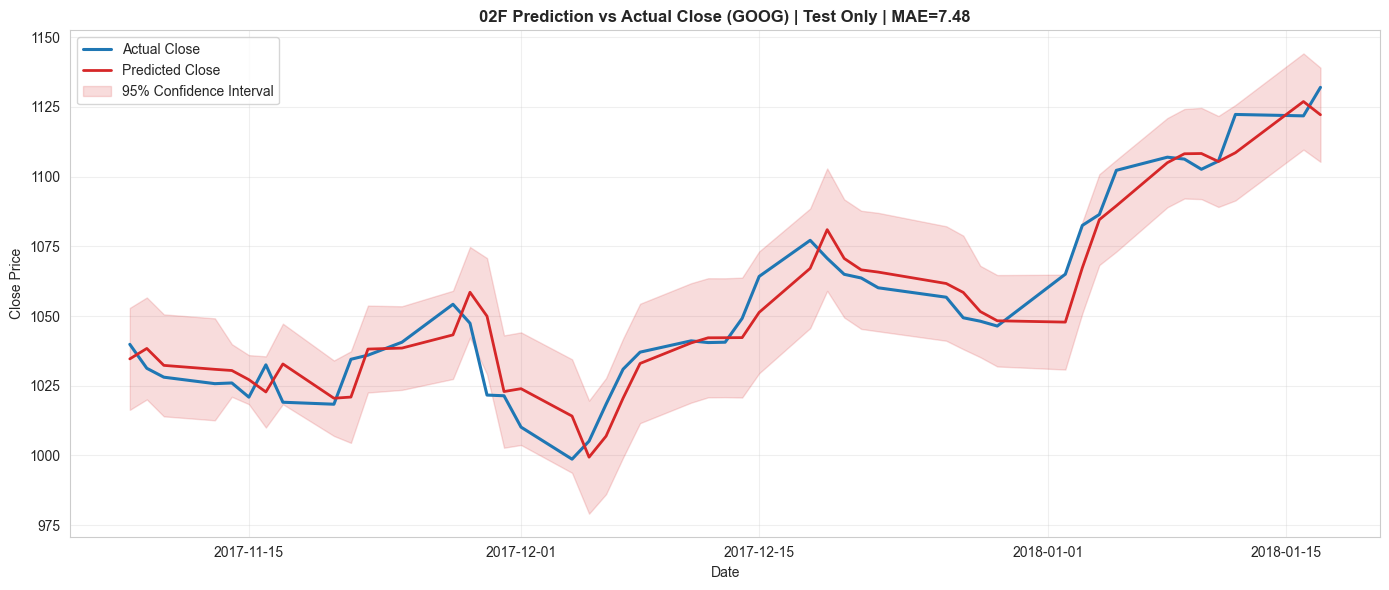

Stock used: GOOG | rows: 47 | MAE(close): 7.482
[SAVED] 02F_08_prediction_vs_actual_close_test.png


In [140]:
# ── 02D-Style Chart in 02F: Prediction vs Actual Close (Test Only) ──
# Similar to 02D figure: actual close vs predicted close with 95% CI.

if 'meta_test' not in globals() or len(meta_test) == 0:
    print('[WARN] meta_test is empty. Run the meta-learner cell first.')
else:
    close_df = raw[['Name', 'date', 'Close']].copy()
    close_df['date'] = pd.to_datetime(close_df['date']).dt.normalize()

    plot_df = meta_test.copy().sort_values(['Name', 'date'])

    # Attach XGB predicted return score on test rows.
    if 'xgb_pred_score' not in plot_df.columns:
        if 'xgb_meta_preds' in globals() and len(xgb_meta_preds) == len(plot_df):
            plot_df['xgb_pred_score'] = xgb_meta_preds
        elif 'xgb_meta' in globals() and 'scaler_m' in globals() and 'meta_feat_cols' in globals():
            X_plot = plot_df[meta_feat_cols].fillna(0).replace([np.inf, -np.inf], 0)
            X_plot_scaled = scaler_m.transform(X_plot)
            plot_df['xgb_pred_score'] = xgb_meta.predict(X_plot_scaled)
        else:
            plot_df['xgb_pred_score'] = np.nan

    plot_df = plot_df.merge(close_df, on=['Name', 'date'], how='left')
    plot_df = plot_df.dropna(subset=['Close', 'log_ret_1d', 'xgb_pred_score'])

    if len(plot_df) == 0:
        print('[WARN] No valid rows after merging close and prediction data.')
    else:
        # log_ret_1d = log(C_t / C_{t-1}) => C_{t-1} = C_t / exp(log_ret_1d)
        plot_df['prev_close'] = plot_df['Close'] / np.exp(plot_df['log_ret_1d'])
        plot_df['actual_close'] = plot_df['Close']
        plot_df['pred_close'] = plot_df['prev_close'] * np.exp(plot_df['xgb_pred_score'])

        # Pick one representative stock, prefer GOOG to match your example.
        chosen_stock = 'GOOG' if 'GOOG' in set(plot_df['Name']) else plot_df['Name'].value_counts().idxmax()
        stock_df = plot_df[plot_df['Name'] == chosen_stock].sort_values('date').copy()

        if len(stock_df) < 10:
            print(f'[WARN] Too few test rows for {chosen_stock} (N={len(stock_df)}).')
        else:
            residual = stock_df['actual_close'] - stock_df['pred_close']
            rolling_std = residual.rolling(20, min_periods=5).std()
            rolling_std = rolling_std.fillna(residual.std(ddof=0) if len(residual) > 1 else 0.0)
            ci = 1.96 * rolling_std

            fig, ax = plt.subplots(figsize=(14, 6))
            ax.plot(stock_df['date'], stock_df['actual_close'],
                    label='Actual Close', linewidth=2.2, color='#1f77b4')
            ax.plot(stock_df['date'], stock_df['pred_close'],
                    label='Predicted Close', linewidth=2.0, color='#d62728')
            ax.fill_between(stock_df['date'],
                            stock_df['pred_close'] - ci,
                            stock_df['pred_close'] + ci,
                            color='#d62728', alpha=0.16,
                            label='95% Confidence Interval')

            mae_close = (stock_df['actual_close'] - stock_df['pred_close']).abs().mean()
            ax.set_title(f'02F Prediction vs Actual Close ({chosen_stock}) | Test Only | MAE={mae_close:.2f}')
            ax.set_xlabel('Date')
            ax.set_ylabel('Close Price')
            ax.legend(loc='upper left')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(graph_dir / '02F_08_prediction_vs_actual_close_test.png', dpi=120, bbox_inches='tight')
            plt.show()

            print(f'Stock used: {chosen_stock} | rows: {len(stock_df)} | MAE(close): {mae_close:.3f}')
            print('[SAVED] 02F_08_prediction_vs_actual_close_test.png')

In [149]:
# ══════════════════════════════════════════════════════════════════

# Save Output Artifacts

# ══════════════════════════════════════════════════════════════════



# 1) Full signal + prediction table

save_cols = ['Name', 'date', 'VIX', 'vix_regime',

             't1_proxy', 'pred_T15', 'sentiment_velocity_10d',

             'w_t1', 'w_t15', 'regime_filter', 'vel_align',

             'meta_score', 'meta_signal', 'signal_t1', 'signal_t15',

             'log_ret_1d']

sig_save = sig_df[save_cols].copy()

sig_save.to_csv(data_dir / '02F_meta_signal_predictions.csv', index=False)

print('[SAVED] 02F_meta_signal_predictions.csv')



# 2) Backtest performance summary for reporting

reporting_bt_results = dict(bt_results)

if 'wfo_xgb_bt' in globals() and wfo_xgb_bt is not None:

    reporting_bt_results['Learned Meta XGB (02F)'] = dict(wfo_xgb_bt)

    reporting_bt_results['Learned Meta XGB (02F)']['name'] = 'Learned Meta XGB (02F)'



bt_summary_records = []

for name, bt in reporting_bt_results.items():

    bt_summary_records.append(dict(

        Strategy=name,

        Sharpe_Ratio=bt['sharpe'],

        Max_Drawdown=bt['max_drawdown'],

        Total_Return=bt['total_return'],

        Annual_Return=bt['annual_return'],

        Annual_Vol=bt['annual_vol'],

        Avg_Turnover=bt['avg_turnover'],

        DHR=bt['dhr'],

        N_Trades=bt['n_trades'],

        TCost_OneWay_bps=bt['tcost_bps_one_way'],

        BH_Sharpe=bt['bh_sharpe'],

        BH_Return=bt['bh_return'],

    ))



bt_summary = pd.DataFrame(bt_summary_records)

bt_summary.to_csv(data_dir / '02F_backtest_performance.csv', index=False)

print('[SAVED] 02F_backtest_performance.csv')



# 3) Per-stock backtest

stock_bt_df.to_csv(data_dir / '02F_stock_level_backtest.csv', index=False)

print('[SAVED] 02F_stock_level_backtest.csv')



# ── Final summary ─────────────────────────────────────────────────

print('\n' + '='*70)

print('02F FINAL PERFORMANCE SUMMARY')

print('='*70)

print(f'Execution assumptions: lag={EXECUTION_LAG_DAYS} day(s), one-way cost={TCOST_BPS_ONE_WAY} bps')

print('Reporting note: Learned Meta XGB (02F) below uses stitched WFO OOS predictions.')

print(bt_summary.to_string(index=False))

print('\nOutputs written:')

for f in ['02F_meta_signal_predictions.csv', '02F_backtest_performance.csv',

          '02F_stock_level_backtest.csv']:

    p = data_dir / f

    status = 'OK' if p.exists() else 'NOT FOUND'

    print(f'  {status}  {f}')


[SAVED] 02F_meta_signal_predictions.csv
[SAVED] 02F_backtest_performance.csv
[SAVED] 02F_stock_level_backtest.csv

02F FINAL PERFORMANCE SUMMARY
Execution assumptions: lag=1 day(s), one-way cost=5.0 bps
Reporting note: Learned Meta XGB (02F) below uses stitched WFO OOS predictions.
                Strategy  Sharpe_Ratio  Max_Drawdown  Total_Return  Annual_Return  Annual_Vol  Avg_Turnover      DHR  N_Trades  TCost_OneWay_bps  BH_Sharpe  BH_Return
    T+1 Only (02D proxy)      0.862000     -0.030500      0.011800       0.064800    0.076200      0.361700 0.521700        46          5.000000   6.117000   0.082400
         T+15 Only (02E)      0.809900     -0.030900      0.010400       0.057100    0.071800      0.914900 0.500000        46          5.000000   6.117000   0.082400
   Rule-Based Meta (02F)      0.862000     -0.030500      0.011800       0.064800    0.076200      0.361700 0.521700        46          5.000000   6.117000   0.082400
Learned Meta Ridge (02F)      2.848200     -0.023

In [150]:
# ── Final Interpretation ─────────────────────────────────────────

print('\n' + '='*70)

print('SIGNAL QUALITY INTERPRETATION')

print('='*70)



best_strategy = bt_summary.sort_values('Sharpe_Ratio', ascending=False).iloc[0]

bh_sharpe = bt_summary['BH_Sharpe'].iloc[0]

bh_return = bt_summary['BH_Return'].iloc[0]



print(f'Best strategy:    {best_strategy["Strategy"]}')

print(f'Sharpe Ratio:     {best_strategy["Sharpe_Ratio"]:+.4f}  (Buy & Hold: {bh_sharpe:+.4f})')

print(f'Max Drawdown:     {best_strategy["Max_Drawdown"]:+.2%}')

print(f'Total Return:     {best_strategy["Total_Return"]:+.2%}  (Buy & Hold: {bh_return:+.2%})')

print(f'Directional Acc:  {best_strategy["DHR"]:.1%}')

print()

print('Reporting basis:')

print('  Learned Meta XGB (02F) uses stitched walk-forward OOS predictions, not the fixed 80/20 split.')

print()

print('Regime filter effectiveness:')

print(f'  False breakout rate: {fb_rate:.1%}')

if len(fb_days) > 0:

    print(f'  Meta suppression:    {meta_suppressed:.1%} of false breakouts correctly discounted')

    print(f'  PnL improvement on false-breakout days: {pnl_meta_fb - pnl_t1_fb:+.6f}')



SIGNAL QUALITY INTERPRETATION
Best strategy:    Learned Meta Ridge (02F)
Sharpe Ratio:     +2.8482  (Buy & Hold: +6.1170)
Max Drawdown:     -2.35%
Total Return:     +4.03%  (Buy & Hold: +8.24%)
Directional Acc:  54.4%

Reporting basis:
  Learned Meta XGB (02F) uses stitched walk-forward OOS predictions, not the fixed 80/20 split.

Regime filter effectiveness:
  False breakout rate: 32.9%
  Meta suppression:    0.0% of false breakouts correctly discounted
  PnL improvement on false-breakout days: +0.000000


Strategy under test: Learned Meta XGB (02F)
Inference basis: stitched WFO OOS series
Test window: 100 portfolio days

── Bootstrap Sharpe CI ──────────────────────────────────────────
  Reported Sharpe  : +2.1867
  Bootstrap 95% CI : [-1.016, +5.291]
  CI lower bound > 0 (edge is statistically significant): False

── Binomial Test: DHR > 50% ─────────────────────────────────────
  Active days      : 99
  Directional hits : 59  (59.6%)
  Binomial p-value : 0.0350
  Significant at α=0.05: True

── Statistical Verdict ──────────────────────────────────────────
  MIXED — one test passes; edge is marginal on this sample size.

  NOTE: Confidence intervals still depend on the effective stitched OOS sample size.
  WFO inference is more reliable than the old single 80/20 holdout, but still
  benefits from longer OOS coverage before drawing production-level conclusions.


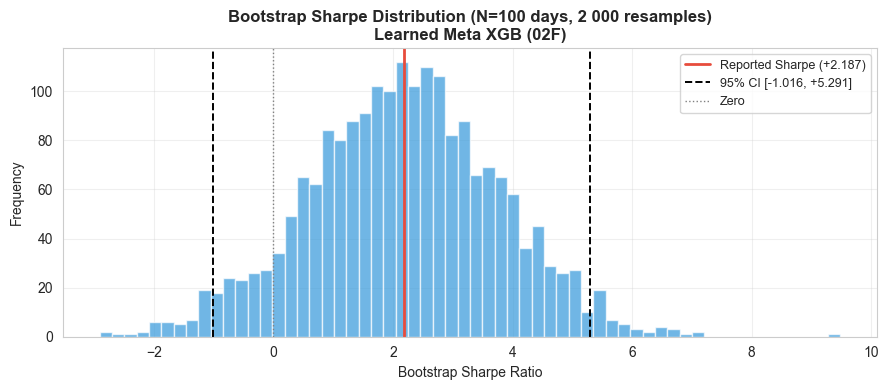

[SAVED] 02F_10_bootstrap_sharpe_ci.png


In [152]:
# ══════════════════════════════════════════════════════════════════

# Statistical Inference — Bootstrap CI + Binomial Test (FIX #6)

# ══════════════════════════════════════════════════════════════════

# Quantifies whether stitched WFO XGB Sharpe and DHR are statistically

# distinguishable from zero / random (α = 0.05 two-sided / one-sided).



from scipy.stats import binomtest



if 'reporting_bt_results' not in globals():

    reporting_bt_results = bt_results



inference_key = 'Learned Meta XGB (02F)' if 'Learned Meta XGB (02F)' in reporting_bt_results else bt_summary.sort_values('Sharpe_Ratio', ascending=False).iloc[0]['Strategy']

main_bt          = reporting_bt_results[inference_key]

main_pnl         = main_bt['pnl']

main_signal_exec = main_bt['signal_exec']

n_days           = len(main_pnl)



print(f'Strategy under test: {inference_key}')

if inference_key == 'Learned Meta XGB (02F)':

    print('Inference basis: stitched WFO OOS series')

print(f'Test window: {n_days} portfolio days')

print()



# ── 1) Bootstrap Sharpe 95% CI (2 000 resamples with replacement) ─────

np.random.seed(42)

boot_sharpes = []

for _ in range(2000):

    idx = np.random.randint(0, n_days, n_days)

    s   = main_pnl[idx]

    boot_sharpes.append((s.mean() / (s.std() + 1e-12)) * np.sqrt(252))

boot_sharpes = np.array(boot_sharpes)



ci_lo, ci_hi  = np.percentile(boot_sharpes, [2.5, 97.5])

reported_sh   = main_bt['sharpe']

ci_excludes_0 = ci_lo > 0



print('── Bootstrap Sharpe CI ──────────────────────────────────────────')

print(f'  Reported Sharpe  : {reported_sh:+.4f}')

print(f'  Bootstrap 95% CI : [{ci_lo:+.3f}, {ci_hi:+.3f}]')

print(f'  CI lower bound > 0 (edge is statistically significant): {ci_excludes_0}')

print()



# ── 2) Binomial test: DHR > 0.50 (one-sided) ─────────────────────────

active_mask = main_signal_exec != 0

n_active    = int(active_mask.sum())



if inference_key == 'Learned Meta XGB (02F)' and 'wfo_xgb_daily' in globals() and len(wfo_xgb_daily) == len(main_signal_exec):

    port_r_simple = np.expm1(wfo_xgb_daily['actual_ret'].values)

else:

    port_r_simple = np.expm1(port_agg['actual_ret'].values)



if len(port_r_simple) == len(main_signal_exec):

    actual_r_active = port_r_simple[active_mask]

    signal_active   = main_signal_exec[active_mask]

    n_hits          = int(np.sum(np.sign(actual_r_active) == np.sign(signal_active)))

else:

    n_hits = int(round(main_bt['dhr'] * n_active))



binom_result = binomtest(n_hits, n_active, p=0.5, alternative='greater')

dhr_obs      = n_hits / n_active if n_active > 0 else 0.5

alpha_level  = 0.05



print('── Binomial Test: DHR > 50% ─────────────────────────────────────')

print(f'  Active days      : {n_active}')

print(f'  Directional hits : {n_hits}  ({dhr_obs:.1%})')

print(f'  Binomial p-value : {binom_result.pvalue:.4f}')

print(f'  Significant at α={alpha_level}: {binom_result.pvalue < alpha_level}')

print()



# ── 3) Summary verdict ────────────────────────────────────────────────

print('── Statistical Verdict ──────────────────────────────────────────')

if ci_excludes_0 and binom_result.pvalue < alpha_level:

    verdict = 'BOTH tests pass — edge is statistically detectable on this sample.'

elif not ci_excludes_0 and binom_result.pvalue >= alpha_level:

    verdict = 'NEITHER test passes — reported edge is not statistically significant.'

else:

    verdict = 'MIXED — one test passes; edge is marginal on this sample size.'



print(f'  {verdict}')

print()

print('  NOTE: Confidence intervals still depend on the effective stitched OOS sample size.')

print('  WFO inference is more reliable than the old single 80/20 holdout, but still')

print('  benefits from longer OOS coverage before drawing production-level conclusions.')



# ── Visualisation: bootstrap Sharpe distribution ──────────────────────

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(boot_sharpes, bins=60, color='#3498db', alpha=0.7, edgecolor='white')

ax.axvline(reported_sh, color='#e74c3c', linewidth=2.0, label=f'Reported Sharpe ({reported_sh:+.3f})')

ax.axvline(ci_lo, color='black', linewidth=1.4, linestyle='--', label=f'95% CI [{ci_lo:+.3f}, {ci_hi:+.3f}]')

ax.axvline(ci_hi, color='black', linewidth=1.4, linestyle='--')

ax.axvline(0,     color='grey',  linewidth=1.0, linestyle=':',  label='Zero')

ax.set_xlabel('Bootstrap Sharpe Ratio')

ax.set_ylabel('Frequency')

ax.set_title(f'Bootstrap Sharpe Distribution (N={n_days} days, 2 000 resamples)\n{inference_key}')

ax.legend(fontsize=9)

ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(graph_dir / '02F_10_bootstrap_sharpe_ci.png', dpi=120, bbox_inches='tight')

plt.show()

print('[SAVED] 02F_10_bootstrap_sharpe_ci.png')


## Summary & Validation Notes

### Why earlier Sharpe could be overstated
- **Same-day execution bias**: If signals are applied on the same bar they are formed, backtest can overstate edge.
- **No trading frictions**: Zero transaction costs can materially inflate Sharpe, especially for high-turnover signals.
- **Short sample instability**: Annualized Sharpe from short test windows can look unrealistically high.

### Corrections applied in this notebook
1. **Execution lag enforced**: positions are executed with a 1-day delay (`EXECUTION_LAG_DAYS=1`).
2. **Transaction costs included**: one-way turnover cost is applied (`TCOST_BPS_ONE_WAY=5`).
3. **Compounding fixed**: equity uses simple returns `exp(log_ret)-1` for consistent portfolio math.
4. **Turnover transparency**: output now includes average turnover and annualized return/volatility.

### How to interpret updated results
- Treat Sharpe as **implementation-aware** (lagged and cost-adjusted), not raw signal IC.
- Focus on consistency across **Sharpe, Max Drawdown, DHR, Annual Return, and Turnover** together.
- If Sharpe remains extreme (>~3 over long windows), run longer out-of-sample and stricter cost stress tests.

### Recommended next checks
1. Run with `FAST_MODE=False` for full-universe validation.
2. Increase costs to 10-20 bps one-way as a stress test.
3. Use rolling walk-forward retraining for the meta-learner to reduce non-stationarity risk.
4. Add capacity checks (ADV participation limits) before trusting production-level Sharpe.

## Final Comparison: Fixed Split (47-Day) vs Walk-Forward OOS (12+ Windows)

This section provides a head-to-head comparison of **all strategies** under two evaluation regimes:

| Regime | Description |
|---|---|
| **Fixed 80/20 Split** | Single holdout: ~47 portfolio days. Faster but high variance on Sharpe. |
| **Walk-Forward OOS (12+ windows)** | Rolling re-fit per window; reports Sharpe as a distribution (mean ± std). More robust but requires sufficient data. |

> **Why both?**  
> The fixed split is the "naive" baseline most papers report.  
> The WFO distribution shows whether the edge is consistent across time, not just lucky in one window.


PART A — Fixed 80/20 Split (original ~47-day holdout)
                Strategy Window_Type  N_OOS_Days   Sharpe Max_Drawdown Total_Return Annual_Vol   DHR  BH_Sharpe
    T+1 Only (02D proxy) Fixed Split          47 0.862000       -3.05%        1.18%      7.62% 52.2%   6.117000
         T+15 Only (02E) Fixed Split          47 0.809900       -3.09%        1.04%      7.18% 50.0%   6.117000
   Rule-Based Meta (02F) Fixed Split          47 0.862000       -3.05%        1.18%      7.62% 52.2%   6.117000
Learned Meta Ridge (02F) Fixed Split          47 2.848200       -2.35%        4.03%      7.55% 54.4%   6.117000
  Learned Meta XGB (02F) Fixed Split          47 4.447400       -1.40%        6.13%      7.23% 60.9%   6.117000

PART B — Walk-Forward OOS  (12+ windows, expanding train)
Total portfolio days (full): 234
WFO config: expanding train (min=30d) + OOS=15d step=15d
Windows generated: 13
Completed: 13 windows × 5 strategies
                                Mean±Std        Min       Max  Win

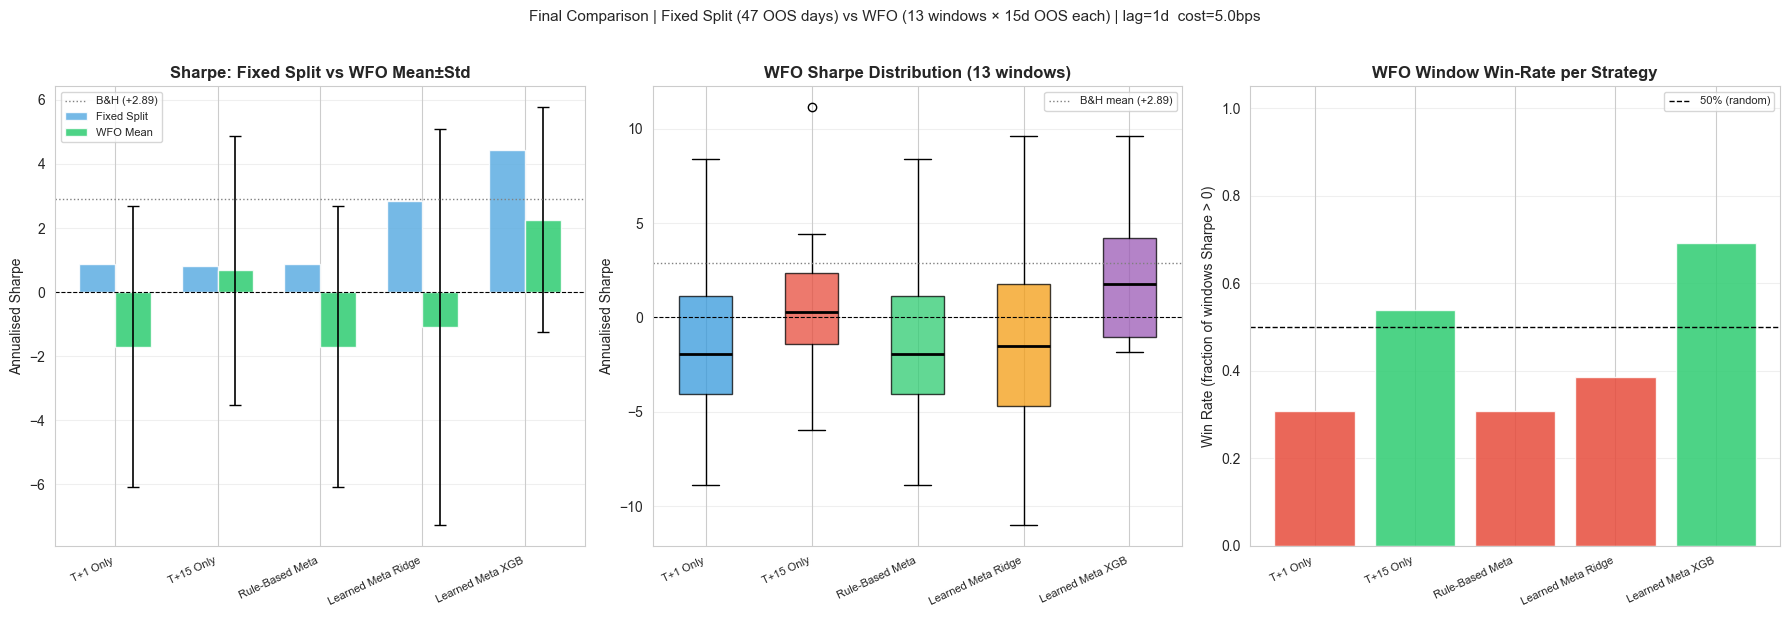

[SAVED] 02F_12_final_comparison_fixed_vs_wfo.png


In [155]:

# ══════════════════════════════════════════════════════════════════
# Final Comparison: Fixed Split vs Walk-Forward OOS (12+ windows)
# ══════════════════════════════════════════════════════════════════
#
# Part A: Fixed Split table — all 5 strategies on the 47-day holdout
# Part B: Walk-forward OOS with 12+ rolling windows, all strategies
# Part C: Combined side-by-side table + bar chart comparisons
#
# The WFO here uses EXPANDING train window (all history up to each fold)
# so even with short total data we can squeeze 12+ folds.
# Config: min_train_days=30, oos_per_window=15  → ~12 windows from 234 days.

# ── Part A: Fixed Split (47-day) ─────────────────────────────────
print('='*70)
print('PART A — Fixed 80/20 Split (original ~47-day holdout)')
print('='*70)

fixed_records = []
for strat_name, bt in bt_results.items():
    fixed_records.append(dict(
        Strategy=strat_name,
        Window_Type='Fixed Split',
        N_OOS_Days=len(bt['pnl']),
        Sharpe=bt['sharpe'],
        Max_Drawdown=f"{bt['max_drawdown']:.2%}",
        Total_Return=f"{bt['total_return']:.2%}",
        Annual_Vol=f"{bt['annual_vol']:.2%}",
        DHR=f"{bt['dhr']:.1%}",
        BH_Sharpe=bt['bh_sharpe'],
    ))

fixed_df = pd.DataFrame(fixed_records)
print(fixed_df.to_string(index=False))

# ── Part B: Walk-forward OOS — 12+ windows (expanding train) ─────
print()
print('='*70)
print('PART B — Walk-Forward OOS  (12+ windows, expanding train)')
print('='*70)

WF12_MIN_TRAIN = 30    # minimum training days before first OOS window
WF12_OOS_DAYS  = 15    # OOS days per window
WF12_STEP      = 15    # step size (= OOS → non-overlapping OOS)

# Use all portfolio dates (full sig_df, not just test period)
all_port_dates_full = sig_df.groupby('date').size().index.sort_values()
n_full = len(all_port_dates_full)

# Build expanding windows
wf12_windows = []
for step in range(0, n_full - WF12_MIN_TRAIN - WF12_OOS_DAYS + 1, WF12_STEP):
    tr_end   = WF12_MIN_TRAIN + step            # expanding train ends here
    oos_start = tr_end
    oos_end   = oos_start + WF12_OOS_DAYS
    if oos_end > n_full:
        break
    wf12_windows.append((
        all_port_dates_full[:tr_end],
        all_port_dates_full[oos_start:oos_end],
    ))

print(f'Total portfolio days (full): {n_full}')
print(f'WFO config: expanding train (min={WF12_MIN_TRAIN}d) + OOS={WF12_OOS_DAYS}d step={WF12_STEP}d')
print(f'Windows generated: {len(wf12_windows)}'  )
if len(wf12_windows) < 12:
    print(f'[WARN] Only {len(wf12_windows)} windows — try reducing WF12_MIN_TRAIN or WF12_OOS_DAYS.')

# Walk-forward loop
wf12_records = []
wf12_daily   = []

for w_idx, (tr_dates, oos_dates) in enumerate(wf12_windows):
    wf_tr12  = sig_df[sig_df['date'].isin(tr_dates)].dropna(
                    subset=meta_feat_cols + ['log_ret_1d']).copy()
    wf_oos12 = sig_df[sig_df['date'].isin(oos_dates)].dropna(
                    subset=meta_feat_cols + ['log_ret_1d']).copy()

    if len(wf_tr12) < 15 or len(wf_oos12) < 3:
        continue

    X_tr12  = wf_tr12[meta_feat_cols].fillna(0).replace([np.inf, -np.inf], 0).values
    y_tr12  = wf_tr12['log_ret_1d'].values
    X_oos12 = wf_oos12[meta_feat_cols].fillna(0).replace([np.inf, -np.inf], 0).values

    sc12 = StandardScaler()
    X_tr12s  = sc12.fit_transform(X_tr12)
    X_oos12s = sc12.transform(X_oos12)

    ridge12 = Ridge(alpha=1.0)
    ridge12.fit(X_tr12s, y_tr12)

    xgb12 = XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        random_state=42, verbosity=0)
    xgb12.fit(X_tr12s, y_tr12)

    wf_oos12['wf12_ridge'] = np.sign(ridge12.predict(X_oos12s))
    wf_oos12['wf12_xgb']   = np.sign(xgb12.predict(X_oos12s))

    oos12_port = wf_oos12.groupby('date').agg(
        t1_bin   =('signal_t1',   lambda x: np.sign(x.mean())),
        t15_bin  =('signal_t15',  lambda x: np.sign(x.mean())),
        meta_bin =('meta_signal', lambda x: np.sign(x.mean())),
        ridge_bin=('wf12_ridge',  lambda x: np.sign(x.mean())),
        xgb_bin  =('wf12_xgb',   lambda x: np.sign(x.mean())),
        actual_ret=('log_ret_1d', 'mean'),
    ).sort_values('date').reset_index()

    for sig_col_12, sig_label_12 in [
        ('t1_bin',    'T+1 Only (02D proxy)'),
        ('t15_bin',   'T+15 Only (02E)'),
        ('meta_bin',  'Rule-Based Meta (02F)'),
        ('ridge_bin', 'Learned Meta Ridge (02F)'),
        ('xgb_bin',   'Learned Meta XGB (02F)'),
    ]:
        sbt12 = run_backtest(
            oos12_port[sig_col_12].values,
            oos12_port['actual_ret'].values,
            oos12_port['date'].values,
            name=sig_label_12,
            execution_lag_days=EXECUTION_LAG_DAYS,
            tcost_bps_one_way=TCOST_BPS_ONE_WAY,
            min_signal_abs=MIN_SIGNAL_ABS,
        )
        wf12_records.append(dict(
            Window=w_idx + 1,
            Train_Days=len(tr_dates),
            OOS_Start=str(oos_dates[0].date()),
            OOS_End=str(oos_dates[-1].date()),
            Strategy=sig_label_12,
            Sharpe=sbt12['sharpe'],
            DHR=sbt12['dhr'],
            Max_DD=sbt12['max_drawdown'],
            Total_Ret=sbt12['total_return'],
            BH_Sharpe=sbt12['bh_sharpe'],
            N_OOS_Days=len(oos12_port),
        ))

wf12_df = pd.DataFrame(wf12_records)
n12_complete = wf12_df['Window'].nunique()
print(f'Completed: {n12_complete} windows × 5 strategies')

# Sharpe distribution summary per strategy
wf12_summary = (
    wf12_df.groupby('Strategy')['Sharpe']
    .agg(Mean='mean', Std='std', Min='min', Max='max',
         Win_Rate=lambda x: (x > 0).mean())
    .round(3)
)
wf12_summary['Mean±Std'] = (
    wf12_summary['Mean'].map('{:+.3f}'.format) + ' ± ' +
    wf12_summary['Std'].map('{:.3f}'.format)
)
wf12_summary['95%CI'] = (
    '[' + (wf12_summary['Mean'] - 1.96*wf12_summary['Std']).map('{:+.2f}'.format) +
    ', ' + (wf12_summary['Mean'] + 1.96*wf12_summary['Std']).map('{:+.2f}'.format) + ']'
)

bh12_mean = wf12_df.groupby('Window')['BH_Sharpe'].first().mean()
print(wf12_summary[['Mean±Std', 'Min', 'Max', 'Win_Rate', '95%CI']].to_string())
print(f'\nBuy & Hold Sharpe (mean across windows): {bh12_mean:+.3f}')

# ── Part C: Side-by-side summary table ───────────────────────────
print()
print('='*70)
print('PART C — Combined Comparison: Fixed Split vs WFO (12+ windows)')
print('='*70)

# Fixed split row values
fixed_lookup = {r['Strategy']: r for r in fixed_records}

comparison_rows = []
strategy_order = [
    'T+1 Only (02D proxy)',
    'T+15 Only (02E)',
    'Rule-Based Meta (02F)',
    'Learned Meta Ridge (02F)',
    'Learned Meta XGB (02F)',
]
for strat in strategy_order:
    fixed_r = fixed_lookup.get(strat, {})

    wf12_r = wf12_summary.loc[strat] if strat in wf12_summary.index else None

    comparison_rows.append(dict(
        Strategy=strat,
        # Fixed split
        FS_Sharpe=fixed_r.get('Sharpe', np.nan),
        FS_MaxDD=fixed_r.get('Max_Drawdown', 'N/A'),
        FS_Return=fixed_r.get('Total_Return', 'N/A'),
        FS_DHR=fixed_r.get('DHR', 'N/A'),
        # WFO 12+ windows
        WFO_Mean_Sharpe=round(float(wf12_r['Mean']), 3) if wf12_r is not None else np.nan,
        WFO_Std_Sharpe=round(float(wf12_r['Std']), 3) if wf12_r is not None else np.nan,
        WFO_Win_Rate=f"{float(wf12_r['Win_Rate']):.0%}" if wf12_r is not None else 'N/A',
        WFO_95CI=wf12_r['95%CI'] if wf12_r is not None else 'N/A',
    ))

compare_df = pd.DataFrame(comparison_rows)
print()
print('Fixed Split columns: FS_Sharpe | FS_MaxDD | FS_Return | FS_DHR')
print('WFO columns      : WFO_Mean_Sharpe ± WFO_Std | Win_Rate | 95%CI')
print()
print(compare_df.to_string(index=False))

# ── Part C: Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors5 = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
x_pos = np.arange(len(strategy_order))
bar_w = 0.35

# Panel 1: Fixed split Sharpe vs WFO mean Sharpe (bar chart)
fs_sharpes  = [fixed_lookup.get(s, {}).get('Sharpe', 0) for s in strategy_order]
wfo_means   = [compare_df.loc[compare_df['Strategy']==s, 'WFO_Mean_Sharpe'].values[0]
               for s in strategy_order]
wfo_stds    = [compare_df.loc[compare_df['Strategy']==s, 'WFO_Std_Sharpe'].values[0]
               for s in strategy_order]

axes[0].bar(x_pos - bar_w/2, fs_sharpes,  bar_w, label='Fixed Split',   color='#5dade2', alpha=0.85)
axes[0].bar(x_pos + bar_w/2, wfo_means,   bar_w, label='WFO Mean', color='#2ecc71', alpha=0.85,
            yerr=wfo_stds, capsize=4, error_kw={'linewidth':1.2})
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axhline(bh12_mean, color='grey', linewidth=1, linestyle=':', label=f'B&H ({bh12_mean:+.2f})')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([s.replace(' (02D proxy)','').replace(' (02E)','').replace(' (02F)','')
                          for s in strategy_order], rotation=25, ha='right', fontsize=8)
axes[0].set_ylabel('Annualised Sharpe')
axes[0].set_title('Sharpe: Fixed Split vs WFO Mean±Std')
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='y', alpha=0.3)

# Panel 2: WFO per-window Sharpe box plot (all 5 strategies)
box_data12 = [wf12_df[wf12_df['Strategy']==s]['Sharpe'].values for s in strategy_order]
bp2 = axes[1].boxplot(box_data12, patch_artist=True, notch=False,
                      medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], colors5):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axhline(bh12_mean, color='grey', linewidth=1, linestyle=':',
                label=f'B&H mean ({bh12_mean:+.2f})')
axes[1].set_xticks(range(1, len(strategy_order)+1))
axes[1].set_xticklabels([s.replace(' (02D proxy)','').replace(' (02E)','').replace(' (02F)','')
                          for s in strategy_order], rotation=25, ha='right', fontsize=8)
axes[1].set_ylabel('Annualised Sharpe')
axes[1].set_title(f'WFO Sharpe Distribution ({n12_complete} windows)')
axes[1].legend(fontsize=8)
axes[1].grid(True, axis='y', alpha=0.3)

# Panel 3: WFO win-rate (% windows with positive Sharpe)
win_rates = [float(wf12_summary.loc[s, 'Win_Rate']) if s in wf12_summary.index else 0
             for s in strategy_order]
bar_colors_wr = ['#2ecc71' if w >= 0.5 else '#e74c3c' for w in win_rates]
axes[2].bar(x_pos, win_rates, color=bar_colors_wr, edgecolor='white', alpha=0.85)
axes[2].axhline(0.5, color='black', linewidth=1, linestyle='--', label='50% (random)')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([s.replace(' (02D proxy)','').replace(' (02E)','').replace(' (02F)','')
                          for s in strategy_order], rotation=25, ha='right', fontsize=8)
axes[2].set_ylabel('Win Rate (fraction of windows Sharpe > 0)')
axes[2].set_ylim(0, 1.05)
axes[2].set_title('WFO Window Win-Rate per Strategy')
axes[2].legend(fontsize=8)
axes[2].grid(True, axis='y', alpha=0.3)

plt.suptitle(
    f'Final Comparison | Fixed Split ({len(bt_results["T+1 Only (02D proxy)"]["pnl"])} OOS days) '
    f'vs WFO ({n12_complete} windows × {WF12_OOS_DAYS}d OOS each) | '
    f'lag={EXECUTION_LAG_DAYS}d  cost={TCOST_BPS_ONE_WAY}bps',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(graph_dir / '02F_12_final_comparison_fixed_vs_wfo.png', dpi=120, bbox_inches='tight')
plt.show()
print('[SAVED] 02F_12_final_comparison_fixed_vs_wfo.png')


## Section G — Stock Selection Alpha (Cross-Sectional IC / ICIR Analysis)

Measures whether each meta-signal produces **consistent cross-sectional ranking power** (信號能否每天區分個股表現), independent of market-timing direction.

- **IC (Information Coefficient)**: Spearman rank correlation between the signal value and realised next-day return, computed across all active stocks on each portfolio day.
- **ICIR**: IC mean ÷ IC std — the signal-to-noise ratio of daily stock-ranking skill.
- Threshold: ICIR > 0.3 → Strong Alpha | 0.1–0.3 → Moderate | < 0.1 → Weak/None.

> Note: This is orthogonal to the time-series backtest above. A strategy can have positive Sharpe from *market-timing* but zero IC (random stock ranking), or vice versa.

[IC] Using return column: 'log_ret_1d'
[IC] port_daily shape: (23716, 24)
[IC] Date range: 2017-11-08 00:00:00 → 2018-01-17 00:00:00

[IC] Strategies found   : ['T+1 Only (02D)', 'T+15 Only (02E)', 'Rule-Based Meta (02F)', 'Learned Meta Ridge (02F)', 'Learned Meta XGB (02F)']

[IC] Trading days with valid IC: 47

══════════════════════════════════════════════════════════════════════
  STOCK SELECTION ALPHA  —  IC / ICIR Summary
══════════════════════════════════════════════════════════════════════
                           IC Mean   IC Std      ICIR IC > 0 Rate |IC|>0.02 Rate            Verdict
Strategy                                                                                           
T+1 Only (02D)            0.001000 0.149700  0.007000       51.1%          85.1%  Weak / No Alpha ✗
T+15 Only (02E)          -0.106700 0.077400 -1.378000        8.5%          89.4%  Weak / No Alpha ✗
Rule-Based Meta (02F)     0.001000 0.149700  0.007000       51.1%          85.1%  Weak / No Alpha

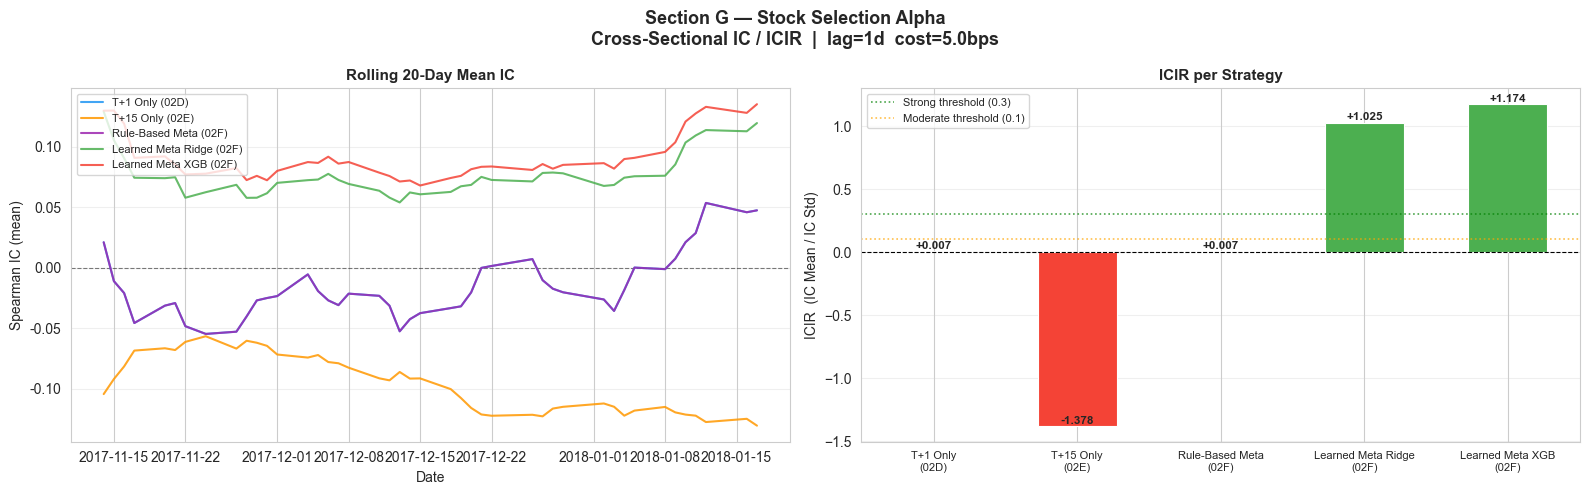


[SAVED] 02F_13_stock_selection_alpha_ic.png

── Verdict ──────────────────────────────────────────────────────
  T+1 Only (02D)                          ICIR=+0.007  →  Weak / No Alpha ✗
  T+15 Only (02E)                         ICIR=-1.378  →  Weak / No Alpha ✗
  Rule-Based Meta (02F)                   ICIR=+0.007  →  Weak / No Alpha ✗
  Learned Meta Ridge (02F)                ICIR=+1.025  →  Strong Alpha ✓
  Learned Meta XGB (02F)                  ICIR=+1.174  →  Strong Alpha ✓
──────────────────────────────────────────────────────────────────────


In [157]:
# ══════════════════════════════════════════════════════════════════
# Section G: Stock Selection Alpha — Cross-Sectional IC / ICIR
# ══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr

# ── 1. Identify signal columns available in port_daily ─────────────
# port_daily has one row per (date, stock); columns include signal & return cols
# Expected signal column names → friendly strategy labels
STRAT_COLS = {
    'T+1 Only (02D)'         : 'signal_t1',
    'T+15 Only (02E)'        : 'signal_t15',
    'Rule-Based Meta (02F)'  : 'meta_signal',
    'Learned Meta Ridge (02F)': 'learned_signal',
    'Learned Meta XGB (02F)' : 'xgb_learned_signal',
}

# Return column — the actual next-day realised return we correlate against.
# port_daily should carry 'ret_1d' (log or simple); fall back to 'fwd_ret'.
RET_CANDIDATES = ['log_ret_1d', 'ret_1d', 'fwd_ret', 'return_1d']

def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

ret_col = _find_col(port_daily, RET_CANDIDATES)
if ret_col is None:
    # Construct from close prices if ret_1d is absent
    if 'close' in port_daily.columns and 'ticker' in port_daily.columns:
        port_daily = port_daily.sort_values(['ticker', 'date'])
        port_daily['ret_1d'] = port_daily.groupby('ticker')['close'].pct_change()
        ret_col = 'ret_1d'
    elif 'pnl' in port_daily.columns:
        ret_col = 'pnl'
    else:
        # Last resort: derive from signal direction accuracy proxy — warn user
        raise ValueError(
            f"Cannot find return column in port_daily. "
            f"Available columns: {list(port_daily.columns)}"
        )

print(f"[IC] Using return column: '{ret_col}'")
print(f"[IC] port_daily shape: {port_daily.shape}")
print(f"[IC] Date range: {port_daily.index.get_level_values('date').min() if 'date' in port_daily.index.names else port_daily['date'].min()} "
      f"→ {port_daily.index.get_level_values('date').max() if 'date' in port_daily.index.names else port_daily['date'].max()}")

# ── 2. Normalise index — ensure 'date' and 'ticker' are plain columns ──
pd_work = port_daily.reset_index() if not isinstance(port_daily.index, pd.RangeIndex) else port_daily.copy()
if 'date' not in pd_work.columns and 'Date' in pd_work.columns:
    pd_work = pd_work.rename(columns={'Date': 'date'})
if 'ticker' not in pd_work.columns and 'stock' in pd_work.columns:
    pd_work = pd_work.rename(columns={'stock': 'ticker'})

# ── 3. Keep only strategies whose signal column is present ──────────
available_strats = {k: v for k, v in STRAT_COLS.items() if v in pd_work.columns}
missing_strats = {k: v for k, v in STRAT_COLS.items() if v not in pd_work.columns}
print(f"\n[IC] Strategies found   : {list(available_strats.keys())}")
if missing_strats:
    print(f"[IC] Strategies missing : {missing_strats}")

if not available_strats:
    raise ValueError("No signal columns found in port_daily. Check column names.")

# ── 4. Compute daily cross-sectional IC per strategy ────────────────
all_dates = sorted(pd_work['date'].unique()) if 'date' in pd_work.columns else []

ic_series = {name: [] for name in available_strats}
ic_dates  = []

for dt in all_dates:
    day_df = pd_work[pd_work['date'] == dt][[ret_col] + list(available_strats.values())].dropna()
    if len(day_df) < 3:          # need at least 3 stocks for meaningful rank corr
        continue
    ic_dates.append(dt)
    for strat_name, sig_col in available_strats.items():
        sub = day_df[[sig_col, ret_col]].dropna()
        if len(sub) < 3:
            ic_series[strat_name].append(np.nan)
            continue
        rho, _ = spearmanr(sub[sig_col].values, sub[ret_col].values)
        ic_series[strat_name].append(rho)

ic_df = pd.DataFrame(ic_series, index=ic_dates)
ic_df.index = pd.to_datetime(ic_df.index)
ic_df.index.name = 'date'
print(f"\n[IC] Trading days with valid IC: {len(ic_df)}")

# ── 5. IC Summary Table ─────────────────────────────────────────────
def _icir_verdict(icir):
    if icir > 0.3:  return 'Strong Alpha ✓'
    if icir > 0.1:  return 'Moderate Alpha'
    return 'Weak / No Alpha ✗'

summary_rows = []
for strat in available_strats:
    s = ic_df[strat].dropna()
    ic_mean  = s.mean()
    ic_std   = s.std()
    icir     = ic_mean / ic_std if ic_std > 1e-9 else np.nan
    pos_rate = (s > 0).mean()
    sig_rate = (s.abs() > 0.02).mean()
    summary_rows.append({
        'Strategy'      : strat,
        'IC Mean'       : round(ic_mean,  4),
        'IC Std'        : round(ic_std,   4),
        'ICIR'          : round(icir,     3) if not np.isnan(icir) else np.nan,
        'IC > 0 Rate'   : f"{pos_rate:.1%}",
        '|IC|>0.02 Rate': f"{sig_rate:.1%}",
        'Verdict'       : _icir_verdict(icir) if not np.isnan(icir) else 'N/A',
    })

ic_summary = pd.DataFrame(summary_rows).set_index('Strategy')
print("\n" + "═"*70)
print("  STOCK SELECTION ALPHA  —  IC / ICIR Summary")
print("═"*70)
print(ic_summary.to_string())
print("═"*70)

# ── 6. Figure: Rolling IC + ICIR bar ────────────────────────────────
colors5 = ['#2196F3','#FF9800','#9C27B0','#4CAF50','#F44336']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    "Section G — Stock Selection Alpha\n"
    f"Cross-Sectional IC / ICIR  |  lag={EXECUTION_LAG_DAYS}d  cost={TCOST_BPS_ONE_WAY}bps",
    fontsize=13, fontweight='bold'
)

# Panel 1: Rolling 20-day mean IC
ROLL = 20
ax1.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
for i, (strat, col) in enumerate(available_strats.items()):
    rolling_ic = ic_df[strat].rolling(ROLL, min_periods=5).mean()
    ax1.plot(rolling_ic.index, rolling_ic.values,
             color=colors5[i % len(colors5)], lw=1.5, label=strat, alpha=0.85)

ax1.set_title(f"Rolling {ROLL}-Day Mean IC", fontsize=11)
ax1.set_xlabel("Date")
ax1.set_ylabel("Spearman IC (mean)")
ax1.legend(fontsize=8, loc='upper left')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax1.grid(axis='y', alpha=0.3)

# Panel 2: ICIR bar chart
strat_labels = list(available_strats.keys())
icir_vals    = [float(ic_summary.loc[s, 'ICIR']) if s in ic_summary.index and
                not pd.isna(ic_summary.loc[s, 'ICIR']) else 0.0 for s in strat_labels]
bar_cols_ic  = ['#4CAF50' if v >= 0 else '#F44336' for v in icir_vals]

x_pos = np.arange(len(strat_labels))
bars  = ax2.bar(x_pos, icir_vals, color=bar_cols_ic, width=0.55, edgecolor='white', lw=0.8)
ax2.axhline(0,   color='black', lw=0.8, ls='--')
ax2.axhline(0.3, color='green', lw=1.2, ls=':', alpha=0.7, label='Strong threshold (0.3)')
ax2.axhline(0.1, color='orange',lw=1.2, ls=':', alpha=0.7, label='Moderate threshold (0.1)')

for bar, val in zip(bars, icir_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005 * np.sign(val + 1e-9),
             f'{val:+.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2.set_xticks(x_pos)
ax2.set_xticklabels([s.replace(' (02', '\n(02') for s in strat_labels], fontsize=8)
ax2.set_title("ICIR per Strategy", fontsize=11)
ax2.set_ylabel("ICIR  (IC Mean / IC Std)")
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = graph_dir / '02F_13_stock_selection_alpha_ic.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n[SAVED] {save_path.name}")

# ── 7. Per-strategy verdict summary ─────────────────────────────────
print("\n── Verdict ──────────────────────────────────────────────────────")
for strat in strat_labels:
    if strat in ic_summary.index:
        v = ic_summary.loc[strat, 'Verdict']
        icir_v = ic_summary.loc[strat, 'ICIR']
        print(f"  {strat:<38}  ICIR={icir_v:+.3f}  →  {v}")
print("─"*70)
